<h2 style="text-align: center; color: #333; font-family: sans-serif;">Importing Libraries</h2>
<hr style="border: 1px solid #ddd;">

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from mplsoccer import Pitch
import numpy as np

import requests
from PIL import Image
from mplsoccer import Pitch
from matplotlib.offsetbox import OffsetImage, AnnotationBbox


<h2 style="text-align: left; color: #333; font-family: sans-serif; font-size :20px" >  Acessing the underStats Page to see the available matches for the week</h2>
<hr style="border: 1px solid #ddd;">

In [3]:
def get_page(league: str, season: int) -> dict:
    """
    Fetch Understat league data and return teams dictionary.

    Parameters
    ----------
    league : str
        League code, e.g. 'EPL', 'LaLiga', 'Bundesliga'
    season : int
        Season start year, e.g. 2025

    Returns
    -------
    dict
        data['teams']
    """

    url = f"https://understat.com/getLeagueData/{league}/{season}"

    headers = {
        "Accept": "application/json, text/javascript, */*; q=0.01",
        "User-Agent": (
            "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
            "AppleWebKit/537.36 (KHTML, like Gecko) "
            "Chrome/120.0.0.0 Safari/537.36"
        ),
        "X-Requested-With": "XMLHttpRequest",
        "Referer": f"https://understat.com/league/{league}/{season}",
    }

    response = requests.get(url, headers=headers, timeout=15)
    response.raise_for_status()

    data = response.json()
    return data['dates']

In [4]:
data = get_page('EPL', 2026)

In [5]:
def get_matches_for_week(league, year):
    data = get_page(league, year)
    matches = []

    for match in data:
        matches.append({
            'home_team': match['h']['title'],
            'away_team': match['a']['title'],
            'home_goals': match['goals']['h'],
            'away_goals': match['goals']['a'],
            'home_xG': match['xG']['h'],
            'away_xG': match['xG']['a'],
            'datetime': match['datetime']
        })

    df = pd.DataFrame(matches)
    df = df[df['home_goals'].notna()].reset_index(drop=True)

    df['home_xG'] = df['home_xG'].astype(float).round(2)
    df['away_xG'] = df['away_xG'].astype(float).round(2)
    
    return df

In [6]:
df = get_matches_for_week('EPL', 2026)

In [7]:
df

,home_team,away_team,home_goals,away_goals,home_xG,away_xG,datetime
0,Arsenal,Coventry,3,0,1.85,0.56,2026-08-21 19:00:00
1,Hull,Manchester United,2,0,1.50,1.78,2026-08-22 11:30:00
2,Everton,Crystal Palace,2,0,1.45,2.23,2026-08-22 14:00:00
3,Ipswich,Sunderland,2,1,1.58,1.18,2026-08-22 14:00:00
4,Nottingham Forest,Leeds,0,1,0.66,0.47,2026-08-22 14:00:00
5,Brentford,Tottenham,3,0,4.04,0.76,2026-08-22 16:30:00
6,Brighton,Aston Villa,4,0,4.00,0.28,2026-08-23 13:00:00
7,Manchester City,Bournemouth,2,1,2.47,0.71,2026-08-23 13:00:00
8,Newcastle United,Liverpool,2,2,1.59,3.13,2026-08-23 15:30:00
9,Fulham,Chelsea,2,3,1.42,2.58,2026-08-24 19:00:00



<h2 style="text-align: left; color: #333; font-family: sans-serif; font-size : 15px">we are interested in the Arsenal & Aston Villa match</h2>
<hr style="border: 1px solid #ddd;">

Using the understatapi to acess the match data

In [8]:
from understatapi import UnderstatClient

understat = UnderstatClient()
team_match_data = understat.team(team="Arsenal").get_match_data(season="2026")


In [9]:
matches = team_match_data

In [10]:
match_id = "31199"

In [11]:
roster_data = understat.match(match=match_id).get_roster_data()

In [12]:
roster_data

{'h': {'798265': {'id': '798265',
   'goals': '0',
   'own_goals': '0',
   'shots': '0',
   'xG': '0',
   'time': '90',
   'player_id': '12781',
   'team_id': '71',
   'position': 'GK',
   'player': 'Zion Suzuki',
   'h_a': 'h',
   'yellow_card': '0',
   'red_card': '0',
   'roster_in': '0',
   'roster_out': '0',
   'key_passes': '0',
   'assists': '0',
   'xA': '0',
   'xGChain': '0.0823236033320427',
   'xGBuildup': '0.0823236033320427',
   'positionOrder': '1'},
  '798266': {'id': '798266',
   'goals': '0',
   'own_goals': '0',
   'shots': '1',
   'xG': '0.07843043655157089',
   'time': '79',
   'player_id': '8864',
   'team_id': '71',
   'position': 'DR',
   'player': 'Matthew Cash',
   'h_a': 'h',
   'yellow_card': '0',
   'red_card': '0',
   'roster_in': '798278',
   'roster_out': '0',
   'key_passes': '0',
   'assists': '0',
   'xA': '0',
   'xGChain': '0.12047496438026428',
   'xGBuildup': '0.04204452782869339',
   'positionOrder': '2'},
  '798268': {'id': '798268',
   'goals':

In [13]:
all_players = []
for team_key in ['h', 'a']:
    if team_key in roster_data:
        all_players.extend(roster_data[team_key].values())

In [14]:
pd.set_option('display.max_columns', None)


In [15]:
df = pd.DataFrame(all_players)

| Metric | What it tells you |
|---|---|
| Goals | Actual finishing |
| xG | Quality of chances |
| Shots | Shooting volume |
| xG/Shot | Average shot quality |
| Assists | Actual creation |
| xA | Quality of chances created |
| Key passes | Chance-creation volume |
| xGChain | Involvement in dangerous possessions |
| xGBuildup | Contribution to attacking buildup |
| Yellow/Red cards | Discipline |

In [16]:
df

,id,goals,own_goals,shots,xG,time,player_id,team_id,position,player,h_a,yellow_card,red_card,roster_in,roster_out,key_passes,assists,xA,xGChain,xGBuildup,positionOrder
0,798265,0,0,0,0,90,12781,71,GK,Zion Suzuki,h,0,0,0,0,0,0,0,0.0823236033320427,0.0823236033320427,1
1,798266,0,0,1,0.07843043655157089,79,8864,71,DR,Matthew Cash,h,0,0,798278,0,0,0,0,0.12047496438026428,0.04204452782869339,2
2,798268,0,0,0,0,90,6080,71,DC,Victor Lindelöf,h,0,0,0,0,0,0,0,0.0402790792286396,0.0402790792286396,3
3,798267,0,0,0,0,90,6221,71,DC,Pau Torres,h,0,0,0,0,0,0,0,0.0402790792286396,0.0402790792286396,3
4,798269,0,0,2,0.0823236033320427,90,11807,71,DL,Ian Maatsen,h,1,0,0,0,0,0,0,0.10969644784927368,0.06765192002058029,4
5,798271,0,0,1,0.03606048598885536,79,592,71,DMC,Ross Barkley,h,0,0,798276,0,2,0,0.0823236033320427,0.14575693011283875,0.06765192002058029,7
6,798270,0,0,0,0,90,5789,71,DMC,Boubacar Kamara,h,0,0,0,0,1,0,0.02737284079194069,0.10969644784927368,0.10969644784927368,7
7,798272,0,0,2,0.057737477123737335,90,7723,71,AMR,John McGinn,h,1,0,0,0,1,0,0.07843043655157089,0.17821243405342102,0.04204452782869339,11
8,798273,0,0,1,0.02737284079194069,90,2203,71,AMC,Emiliano Buendía,h,0,0,0,0,1,0,0.020744293928146362,0.13044074177742004,0.0823236033320427,12
9,798274,0,0,0,0,72,14193,71,AML,George Hemmings,h,0,0,798277,0,0,0,0,0.061023373156785965,0.061023373156785965,13


In [17]:
numeric_cols = [
    'goals',
    'own_goals',
    'shots',
    'xG',
    'time',
    'yellow_card',
    'red_card',
    'key_passes',
    'assists',
    'xA',
    'xGChain',
    'xGBuildup',
    'positionOrder',
]

df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric)

print(df.head())

       id  goals  own_goals  shots        xG  time player_id team_id position  \
0  798265      0          0      0  0.000000    90     12781      71       GK   
1  798266      0          0      1  0.078430    79      8864      71       DR   
2  798268      0          0      0  0.000000    90      6080      71       DC   
3  798267      0          0      0  0.000000    90      6221      71       DC   
4  798269      0          0      2  0.082324    90     11807      71       DL   

            player h_a  yellow_card  red_card roster_in roster_out  \
0      Zion Suzuki   h            0         0         0          0   
1     Matthew Cash   h            0         0    798278          0   
2  Victor Lindelöf   h            0         0         0          0   
3       Pau Torres   h            0         0         0          0   
4      Ian Maatsen   h            1         0         0          0   

   key_passes  assists   xA   xGChain  xGBuildup  positionOrder  
0           0        0  0.

In [18]:
df.dtypes

id                   str
goals              int64
own_goals          int64
shots              int64
xG               float64
time               int64
player_id            str
team_id              str
position             str
player               str
h_a                  str
yellow_card        int64
red_card           int64
roster_in            str
roster_out           str
key_passes         int64
assists            int64
xA               float64
xGChain          float64
xGBuildup        float64
positionOrder      int64
dtype: object

In [19]:
df["team_id"].unique()

<StringArray>
['71', '83']
Length: 2, dtype: str

In [20]:
df.groupby("team_id").size()

team_id
71    15
83    16
dtype: int64

In [21]:
team_stats = df.groupby("team_id").agg(
    goals=("goals", "sum"),
    shots=("shots", "sum"),
    xG=("xG", "sum"),
    assists=("assists", "sum"),
    xA=("xA", "sum"),
    key_passes=("key_passes", "sum"),
    xGChain=("xGChain", "sum"),
    xGBuildup=("xGBuildup", "sum")
).reset_index()

team_stats

,team_id,goals,shots,xG,assists,xA,key_passes,xGChain,xGBuildup
0,71,0,7,0.281925,0,0.208871,5,1.123986,0.741121
1,83,1,7,1.524407,1,1.106264,5,8.934884,6.857243


In [22]:
team_stats["xG_per_shot"] = team_stats["xG"] / team_stats["shots"]

In [23]:
team_stats["finishing_difference"] = (
    team_stats["goals"] - team_stats["xG"]
)

In [24]:
team_stats.round(2)

,team_id,goals,shots,xG,assists,xA,key_passes,xGChain,xGBuildup,xG_per_shot,finishing_difference
0,71,0,7,0.28,0,0.21,5,1.12,0.74,0.04,-0.28
1,83,1,7,1.52,1,1.11,5,8.93,6.86,0.22,-0.52


In [25]:
team_stats.sort_values("xG", ascending=False)

,team_id,goals,shots,xG,assists,xA,key_passes,xGChain,xGBuildup,xG_per_shot,finishing_difference
1,83,1,7,1.524407,1,1.106264,5,8.934884,6.857243,0.217772,-0.524407
0,71,0,7,0.281925,0,0.208871,5,1.123986,0.741121,0.040275,-0.281925


<details open>
<summary><h2>📊 Match Insights Analysis</h2></summary>

| Metric | Team AV | Team A | Key Insight |
| :--- | :---: | :---: | :--- |
| **Goals / Shots** | 0 / 7 | 1 / 7 | **Equal attempts**, but  Arsenal converted. |
| **Expected Goals (xG)** | 0.28 | **1.52** |  Arsenal created **5x higher quality** chances (~0.22 xG/shot vs ~0.04 xG/shot). |
| **Expected Assists (xA)** | 0.21 | **1.11** |  Arsenal's key passes were significantly more dangerous. |
| **xGChain / xGBuildup** | 1.12 / 0.74 | **8.93 / 6.86** | Arsenal heavily dominated overall play and possession flow. |

---

### 🔑 Key Highlights

1. **Shot Quality over Quantity:** Both teams registered **7 shots** and **5 key passes**, but  Aston Villa took low-probability shots, whereas Arsenal created clear-cut chances.
2. **Possession Dominance:**  Arsenal's massive **xGChain (8.93)** shows their core players were constantly involved in dangerous attacking sequences.

<blockquote>
<b>Summary Verdict:</b> Arsenal completely controlled the match quality and deserved their lead, outclassing Aston Villa in every underlying metric despite having the same number of shots.
</blockquote>

</details>

In [26]:
team_name_map = {
    # Replace these with your actual team_id values
    team_stats["team_id"].iloc[1]: "Arsenal",
    team_stats["team_id"].iloc[0]: "Aston Villa"
}

team_stats["team_name"] = team_stats["team_id"].map(team_name_map)

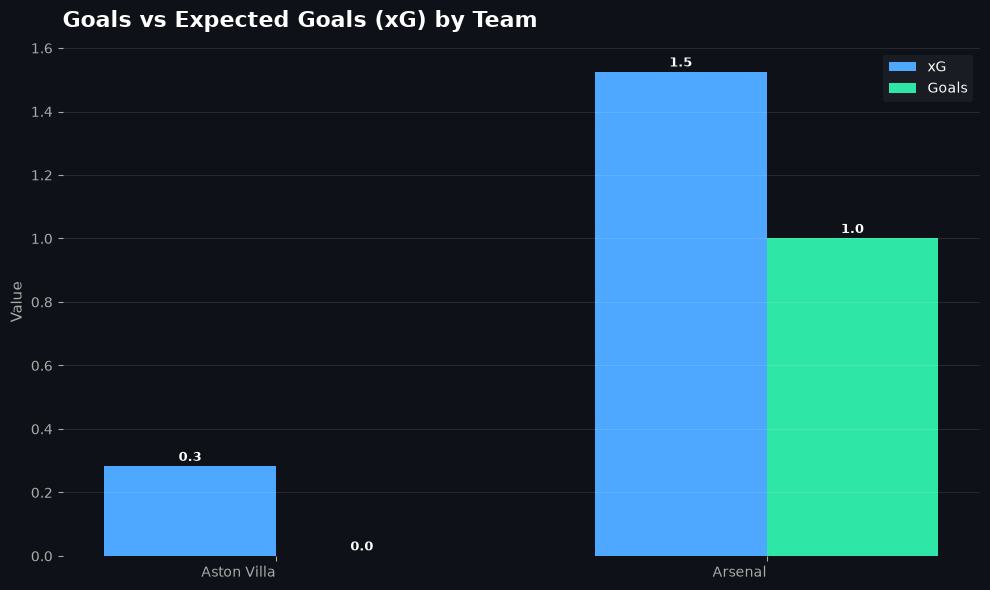

In [27]:

x = np.arange(len(team_stats))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6), facecolor="#0e1117")
ax.set_facecolor("#0e1117")

bars_xg = ax.bar(x - width/2, team_stats["xG"], width, label="xG", color="#4ea8ff")
bars_goals = ax.bar(x + width/2, team_stats["goals"], width, label="Goals", color="#2ee6a6")

# Value labels on top of each bar
for bars in [bars_xg, bars_goals]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(
            f"{height:.1f}",
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 4),
            textcoords="offset points",
            ha="center",
            color="white",
            fontsize=9,
            fontweight="bold"
        )

# Use team names if available, fall back to team_id
labels = team_stats["team_name"] if "team_name" in team_stats.columns else team_stats["team_id"]
ax.set_xticks(x)
ax.set_xticklabels(labels, ha="right", color="white", fontsize=10)

# Styling
ax.set_title("Goals vs Expected Goals (xG) by Team", color="white",
             fontsize=16, fontweight="bold", loc="left", pad=15)
ax.set_ylabel("Value", color="#aaaaaa", fontsize=11)
ax.tick_params(colors="#aaaaaa")
for spine in ax.spines.values():
    spine.set_visible(False)
ax.grid(axis="y", color="white", alpha=0.1)

legend = ax.legend(facecolor="#1c1f26", edgecolor="none", labelcolor="white", fontsize=10)

plt.tight_layout()
plt.show()

<details open>
<summary><h2>⚽ Goals vs Expected Goals (xG) Insights</h2></summary>

| Team | xG (Expected) | Goals (Actual) | Finishing Efficiency | Performance Summary |
| :--- | :---: | :---: | :---: | :--- |
| **Aston Vill** | 0.3 | 0.0 | **Underperformed (-0.3)** | Struggles to generate quality chances and failed to score. |
| **Arsenal** | **1.5** | **1.0** | **Underperformed (-0.5)** | Dominated chance creation; scored 1 goal despite missing ~0.5 xG worth of chances. |

---

###  Key Takeaways

1. **Massive Attacking Gap:** Arsenal created **5x the xG of Aston Vill** (1.5 vs. 0.3), showcasing total offensive dominance in high-value scoring areas.
2. **Finishing Efficiency:** Both teams slightly underperformed relative to their expected goals, but Arsenal's volume advantage secured them a **1–0 victory**.

<blockquote>
<b>Match Narrative:</b> Arsenal was by far the more dangerous side in front of goal, generating high-probability opportunities and earned their 1–0 lead, while Aston Vill created almost no threat.
</blockquote>

</details>

In [28]:
arsenal = df[df["team_id"] == "83"].copy()

top_10 = (
    arsenal
    .sort_values("xG", ascending=False)
    .head(10)
)

top_10[["player", "player_id", "xG", "xA", "shots", "goals"]]

,player,player_id,xG,xA,shots,goals
22,Bukayo Saka,7322,0.975281,0.000000,2,1
18,Gabriel,5613,0.327258,0.000000,1,0
23,Martin Odegaard,2517,0.090885,0.000000,1,0
19,Riccardo Calafiori,8129,0.048702,0.937799,1,0
21,Myles Lewis-Skelly,12272,0.047201,0.000000,1,0
25,Kai Havertz,5220,0.035079,0.000000,1,0
17,Cristhian Mosquera,10024,0.000000,0.000000,0,0
16,Ben White,7298,0.000000,0.035079,0,0
20,Declan Rice,5553,0.000000,0.086185,0,0
15,David Raya,9676,0.000000,0.000000,0,0


In [29]:
arsenal["xGI"] = arsenal["xG"] + arsenal["xA"]

top_10 = (
    arsenal
    .sort_values("xGI", ascending=False)
    .head(10)
)

In [30]:
top_10

,id,goals,own_goals,shots,xG,time,player_id,team_id,position,player,h_a,yellow_card,red_card,roster_in,roster_out,key_passes,assists,xA,xGChain,xGBuildup,positionOrder,xGI
19,798284,0,0,1,0.048702,90,8129,83,DL,Riccardo Calafiori,a,0,0,0,0,1,1,0.937799,0.937799,0.000000,4,0.986501
22,798287,1,0,2,0.975281,90,7322,83,AMR,Bukayo Saka,a,0,0,0,0,0,0,0.000000,1.010361,0.072562,11,0.975281
18,798282,0,0,1,0.327258,90,5613,83,DC,Gabriel,a,0,0,0,0,0,0,0.000000,0.975281,0.975281,3,0.327258
23,798288,0,0,1,0.090885,72,2517,83,AMC,Martin Odegaard,a,0,0,798292,0,0,0,0.000000,0.037483,0.037483,12,0.090885
20,798285,0,0,0,0.000000,86,5553,83,DMC,Declan Rice,a,0,0,798293,0,2,0,0.086185,0.975281,0.937799,7,0.086185
21,798286,0,0,1,0.047201,72,12272,83,DMC,Myles Lewis-Skelly,a,0,0,798291,0,0,0,0.000000,1.022483,0.975281,7,0.047201
24,798289,0,0,0,0.000000,47,9746,83,AML,Christos Tzolis,a,1,0,798294,0,1,0,0.047201,0.047201,0.000000,13,0.047201
16,798281,0,0,0,0.000000,90,7298,83,DR,Ben White,a,0,0,0,0,1,0,0.035079,0.972878,0.937799,2,0.035079
25,798290,0,0,1,0.035079,90,5220,83,FW,Kai Havertz,a,0,0,0,0,0,0,0.000000,0.972878,0.937799,15,0.035079
17,798283,0,0,0,0.000000,80,10024,83,DC,Cristhian Mosquera,a,0,0,798295,0,0,0,0.000000,0.937799,0.937799,3,0.000000


In [31]:
from IPython.display import display, HTML


In [32]:
from ddgs import DDGS
import requests
from pathlib import Path


def search_for_player_image(player, save_folder="images"):
    
    # Create images folder
    Path(save_folder).mkdir(exist_ok=True)
    
    # Search for the player
    query = f"{player} footballer Arsenal"
    
    with DDGS() as ddgs:
        results = list(
            ddgs.images(
                query,
                max_results=1
            )
        )
    
    if not results:
        print(f"No image found for {player}")
        return None
    
    image_url = results[0]["image"]
    
    # Download image
    response = requests.get(
        image_url,
        timeout=10,
        headers={"User-Agent": "Mozilla/5.0"}
    )
    
    if response.status_code != 200:
        print(f"Could not download image for {player}")
        return None
    
    # Safe filename
    filename = "".join(
        c for c in player
        if c.isalnum() or c in " -_"
    ).strip()
    
    path = Path(save_folder) / f"{filename}.jpg"
    
    with open(path, "wb") as f:
        f.write(response.content)
    
    print(f"Downloaded: {player}")
    
    return str(path)

In [33]:
image_path = search_for_player_image("Bukayo Saka")

print(image_path)

Downloaded: Bukayo Saka
images\Bukayo Saka.jpg


In [34]:
top_10[["player", "player_id"]]

,player,player_id
19,Riccardo Calafiori,8129
22,Bukayo Saka,7322
18,Gabriel,5613
23,Martin Odegaard,2517
20,Declan Rice,5553
21,Myles Lewis-Skelly,12272
24,Christos Tzolis,9746
16,Ben White,7298
25,Kai Havertz,5220
17,Cristhian Mosquera,10024


In [35]:
players = {
    8129: "Riccardo Calafiori",
    7322: "Bukayo Saka",
    5613: "Gabriel",
    2517: "Martin Odegaard",
    5553: "Declan Rice",
    12272: "Myles Lewis-Skelly",
    9746: "Christos Tzolis",
    7298: "Ben White",
    5220: "Kai Havertz",
    10024: "Cristhian Mosquera"
}

In [36]:
df[["player", "player_id", "team_id"]].to_string(index=False)

'            player player_id team_id\n       Zion Suzuki     12781      71\n      Matthew Cash      8864      71\n   Victor Lindelöf      6080      71\n        Pau Torres      6221      71\n       Ian Maatsen     11807      71\n      Ross Barkley       592      71\n   Boubacar Kamara      5789      71\n       John McGinn      7723      71\n  Emiliano Buendía      2203      71\n   George Hemmings     14193      71\n   Nicolas Jackson     10048      71\n    Alysson Edward     14446      71\n Aaron Wan-Bissaka      5584      71\nAlejandro Garnacho     10552      71\n     Tammy Abraham       702      71\n        David Raya      9676      83\n         Ben White      7298      83\nCristhian Mosquera     10024      83\n           Gabriel      5613      83\nRiccardo Calafiori      8129      83\n       Declan Rice      5553      83\nMyles Lewis-Skelly     12272      83\n       Bukayo Saka      7322      83\n   Martin Odegaard      2517      83\n   Christos Tzolis      9746      83\n       Kai 

In [37]:
for player in top_10["player"]:

    search_for_player_image(player)


Downloaded: Riccardo Calafiori
Downloaded: Bukayo Saka
Downloaded: Gabriel
Downloaded: Martin Odegaard
Downloaded: Declan Rice
Downloaded: Myles Lewis-Skelly
Downloaded: Christos Tzolis


DDGSException: RequestError: RequestError('error sending request for url (https://duckduckgo.com/?q=Ben+White+footballer+Arsenal) > user error: malformed headers')

In [40]:
from pathlib import Path

image_folder = Path("images")

top_10["image_path"] = top_10["player"].apply(
    lambda name: str(image_folder / f"{name}.jpg")
)

top_10[["player", "image_path"]]

,player,image_path
19,Riccardo Calafiori,images\Riccardo Calafiori.jpg
22,Bukayo Saka,images\Bukayo Saka.jpg
18,Gabriel,images\Gabriel.jpg
23,Martin Odegaard,images\Martin Odegaard.jpg
20,Declan Rice,images\Declan Rice.jpg
21,Myles Lewis-Skelly,images\Myles Lewis-Skelly.jpg
24,Christos Tzolis,images\Christos Tzolis.jpg
16,Ben White,images\Ben White.jpg
25,Kai Havertz,images\Kai Havertz.jpg
17,Cristhian Mosquera,images\Cristhian Mosquera.jpg


In [41]:

# Columns to color-code
stat_cols = ['goals', 'shots', 'xG', 'assists', 'xA', 'xGI']

# Precompute min/max for normalization
col_ranges = {col: (top_10[col].min(), top_10[col].max()) for col in stat_cols}
def get_color(value, col_min, col_max, base_color=(224, 32, 32)):
    """Interpolate font color between light gray (low) and base_color (high)."""
    if col_max == col_min:
        norm = 0.5
    else:
        norm = (value - col_min) / (col_max - col_min)
    
    # Start color (low values) - light gray
    start = (235, 186, 52)
    # End color (high values) - your base color, e.g. Arsenal red
    end = base_color
    
    r = int(start[0] + (end[0] - start[0]) * norm)
    g = int(start[1] + (end[1] - start[1]) * norm)
    b = int(start[2] + (end[2] - start[2]) * norm)
    
    return f"color: rgb({r},{g},{b}); font-weight: {600 if norm > 0.6 else 400};"

rows = ""

for i, (_, row) in enumerate(top_10.iterrows()):
    row_bg = "#f9f9f9" if i % 2 == 0 else "#ffffff"

    goals_style = get_color(row['goals'], *col_ranges['goals'])
    shots_style = get_color(row['shots'], *col_ranges['shots'])
    xg_style = get_color(row['xG'], *col_ranges['xG'])
    assists_style = get_color(row['assists'], *col_ranges['assists'])
    xa_style = get_color(row['xA'], *col_ranges['xA'])
    xgi_style = get_color(row['xGI'], *col_ranges['xGI'])

    rows += f"""
    <tr style="background-color: {row_bg};"
        onmouseover="this.style.opacity='0.85'"
        onmouseout="this.style.opacity='1'">
        <td style="padding: 8px; text-align:center;">
            <img src="{row['image_path']}"
                 width="42" height="42"
                 style="object-fit: cover; border-radius: 50%; border: 2px solid #ddd;">
        </td>
        <td style="padding: 8px; font-weight: 600; color:#1a1a1a;">{row['player']}</td>
        <td style="padding: 8px; text-align:center; border-radius:4px; {goals_style}">{row['goals']}</td>
        <td style="padding: 8px; text-align:center; border-radius:4px; {shots_style}">{row['shots']}</td>
        <td style="padding: 8px; text-align:center; border-radius:4px; {xg_style}">{row['xG']:.2f}</td>
        <td style="padding: 8px; text-align:center; border-radius:4px; {assists_style}">{row['assists']}</td>
        <td style="padding: 8px; text-align:center; border-radius:4px; {xa_style}">{row['xA']:.2f}</td>
        <td style="padding: 8px; text-align:center; border-radius:4px; font-weight:700; {xgi_style}">{row['xGI']:.2f}</td>
    </tr>
    """

html = f"""
<div style="max-width: 900px; margin: 20px 0; font-family: 'Segoe UI', Arial, sans-serif;">
    <h2 style="color:#e02020; margin-bottom: 4px;">⚽ Arsenal Player Attacking Contribution</h2>
    <p style="color:#777; margin-top:0; font-size:13px;">Top 10 players by attacking output · darker cells = higher values</p>

    <table style="
        border-collapse: collapse;
        width: 100%;
        box-shadow: 0 1px 4px rgba(0,0,0,0.1);
        border-radius: 8px;
        overflow: hidden;
    ">
        <thead>
            <tr style="background-color:#e02020; color:white;">
                <th style="padding:10px;">Photo</th>
                <th style="padding:10px; text-align:left;">Player</th>
                <th style="padding:10px;">Goals</th>
                <th style="padding:10px;">Shots</th>
                <th style="padding:10px;">xG</th>
                <th style="padding:10px;">Assists</th>
                <th style="padding:10px;">xA</th>
                <th style="padding:10px;">xGI</th>
            </tr>
        </thead>
        <tbody>
            {rows}
        </tbody>
    </table>
</div>
"""

display(HTML(html))

Photo,Player,Goals,Shots,xG,Assists,xA,xGI
,Riccardo Calafiori,0,1,0.05,1,0.94,0.99
,Bukayo Saka,1,2,0.98,0,0.00,0.98
,Gabriel,0,1,0.33,0,0.00,0.33
,Martin Odegaard,0,1,0.09,0,0.00,0.09
,Declan Rice,0,0,0.00,0,0.09,0.09
,Myles Lewis-Skelly,0,1,0.05,0,0.00,0.05
,Christos Tzolis,0,0,0.00,0,0.05,0.05
,Ben White,0,0,0.00,0,0.04,0.04
,Kai Havertz,0,1,0.04,0,0.00,0.04
,Cristhian Mosquera,0,0,0.00,0,0.00,0.00


<details open>
<summary><h2> Individual Player Performance Insights</h2></summary>

| Player | Shots (xG) | Assists (xA) | xGI | Standout Impact |
| :--- | :---: | :---: | :---: | :--- |
| **Riccardo Calafiori** | 1 (0.05) | **1 (0.94)** | **0.99** | **Primary Playmaker:** Generated nearly 1.0 xA and registered the team's sole assist. |
| **Bukayo Saka** | **2 (0.98)** | 0 (0.00) | **0.98** | **Primary Threat:** Highest xG volume, scoring the team's only goal on high-quality chances. |
| **Gabriel** | 1 (0.33) | 0 (0.00) | 0.33 | **Set-Piece Threat:** High expected goals relative to single attempt. |
| **Martin Ødegaard** | 1 (0.09) | 0 (0.00) | 0.09 | Low overall involvement in direct shot output. |

---

###  Key Takeaways

1. **Top Performers:** **Riccardo Calafiori** (0.99 xGI) and **Bukayo Saka** (0.98 xGI) combined for virtually all of the team's dangerous attacking actions (1.97 xGI total).
2. **Creativity Bottleneck:** Beyond Calafiori's massive **0.94 xA**, playmaking was heavily restricted across the rest of the squad (Declan Rice, Christos Tzolis, and Ben White generated under 0.10 xA each).

<blockquote>
<b>Performance Summary:</b> The team's offensive output was overwhelmingly concentrated in two players: Saka provided the finishing threat, while Calafiori delivered elite chance creation.
</blockquote>

</details>

In [42]:
import plotly.graph_objects as go
import numpy as np
from PIL import Image, ImageDraw
import base64
from io import BytesIO
import requests

def make_circular_image(image_path_or_url, size=100):
    """Crop an image into a circle with transparent background, return as base64 data URI."""
    # Load image (handles both local paths and URLs)
    if image_path_or_url.startswith("http"):
        response = requests.get(image_path_or_url)
        img = Image.open(BytesIO(response.content)).convert("RGBA")
    else:
        img = Image.open(image_path_or_url).convert("RGBA")

    # Resize to a square
    img = img.resize((size, size), Image.LANCZOS)

    # Create circular mask
    mask = Image.new("L", (size, size), 0)
    draw = ImageDraw.Draw(mask)
    draw.ellipse((0, 0, size, size), fill=255)

    # Apply mask as alpha channel
    circular_img = Image.new("RGBA", (size, size))
    circular_img.paste(img, (0, 0), mask=mask)

    # Convert to base64 data URI
    buffer = BytesIO()
    circular_img.save(buffer, format="PNG")
    encoded = base64.b64encode(buffer.getvalue()).decode()
    return f"data:image/png;base64,{encoded}"

# --- Setup ---
x_col, y_col = 'xG', 'xA'
x_vals = top_10[x_col].values
y_vals = top_10[y_col].values
players = top_10['player'].values
images = top_10['image_path'].values

# Pre-process all images into circular base64 versions
circular_images = [make_circular_image(img, size=100) for img in images]

x_mid = np.median(x_vals)
y_mid = np.median(y_vals)

fig = go.Figure()

# --- Invisible scatter for hover tooltips ---
fig.add_trace(go.Scatter(
    x=x_vals,
    y=y_vals,
    mode='markers',
    marker=dict(size=28, color='rgba(0,0,0,0)'),
    hovertemplate=(
        "<b>%{customdata[0]}</b><br>" +
        "xG: %{x:.2f}<br>" +
        "xA: %{y:.2f}<extra></extra>"
    ),
    customdata=np.stack([players], axis=-1),
    showlegend=False
))

# --- Add circular player photos, smaller now ---
for xi, yi, img in zip(x_vals, y_vals, circular_images):
    fig.add_layout_image(
        dict(
            source=img,
            x=xi,
            y=yi,
            xref="x", yref="y",
            sizex=(max(x_vals) - min(x_vals)) * 0.07,   # smaller than before (was 0.12)
            sizey=(max(y_vals) - min(y_vals)) * 0.07,
            xanchor="center",
            yanchor="middle",
            layer="above"
        )
    )

# --- Quadrant divider lines ---
fig.add_shape(type="line", x0=x_mid, x1=x_mid, y0=min(y_vals)*0.9, y1=max(y_vals)*1.1,
              line=dict(color="rgba(255,255,255,0.25)", width=1, dash="dot"))
fig.add_shape(type="line", x0=min(x_vals)*0.9, x1=max(x_vals)*1.1, y0=y_mid, y1=y_mid,
              line=dict(color="rgba(255,255,255,0.25)", width=1, dash="dot"))

# --- Quadrant labels ---
fig.add_annotation(x=max(x_vals)*1.05, y=max(y_vals)*1.08, text="COMPLETE",
                    showarrow=False, font=dict(color="#2ee6a6", size=13, family="Arial Black"),
                    xanchor="right")
fig.add_annotation(x=min(x_vals)*0.95, y=min(y_vals)*0.85, text="STRUGGLING",
                    showarrow=False, font=dict(color="#e04b4b", size=13, family="Arial Black"),
                    xanchor="left")

# --- Axis end labels ---
fig.add_annotation(x=min(x_vals)*0.95, y=max(y_vals)*1.08, text="↑ xA",
                    showarrow=False, font=dict(color="#aaaaaa", size=12), xanchor="left")
fig.add_annotation(x=max(x_vals)*1.05, y=min(y_vals)*0.85, text="xG →",
                    showarrow=False, font=dict(color="#aaaaaa", size=12), xanchor="right")

# --- Layout / dark theme ---
fig.update_layout(
    title=dict(text="Arsenal Players — Attack × Creativity (xG × xA)",
               font=dict(color="white", size=20), x=0.02),
    plot_bgcolor="#0e1117",
    paper_bgcolor="#0e1117",
    xaxis=dict(showgrid=False, zeroline=False, visible=False,
               range=[min(x_vals)*0.85, max(x_vals)*1.15]),
    yaxis=dict(showgrid=False, zeroline=False, visible=False,
               range=[min(y_vals)*0.8, max(y_vals)*1.15]),
    width=750,
    height=550,
    margin=dict(l=40, r=40, t=60, b=40),
    hoverlabel=dict(bgcolor="#1c1f26", font_size=13, font_color="white")
)

fig

In [43]:
from adjustText import adjust_text

Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


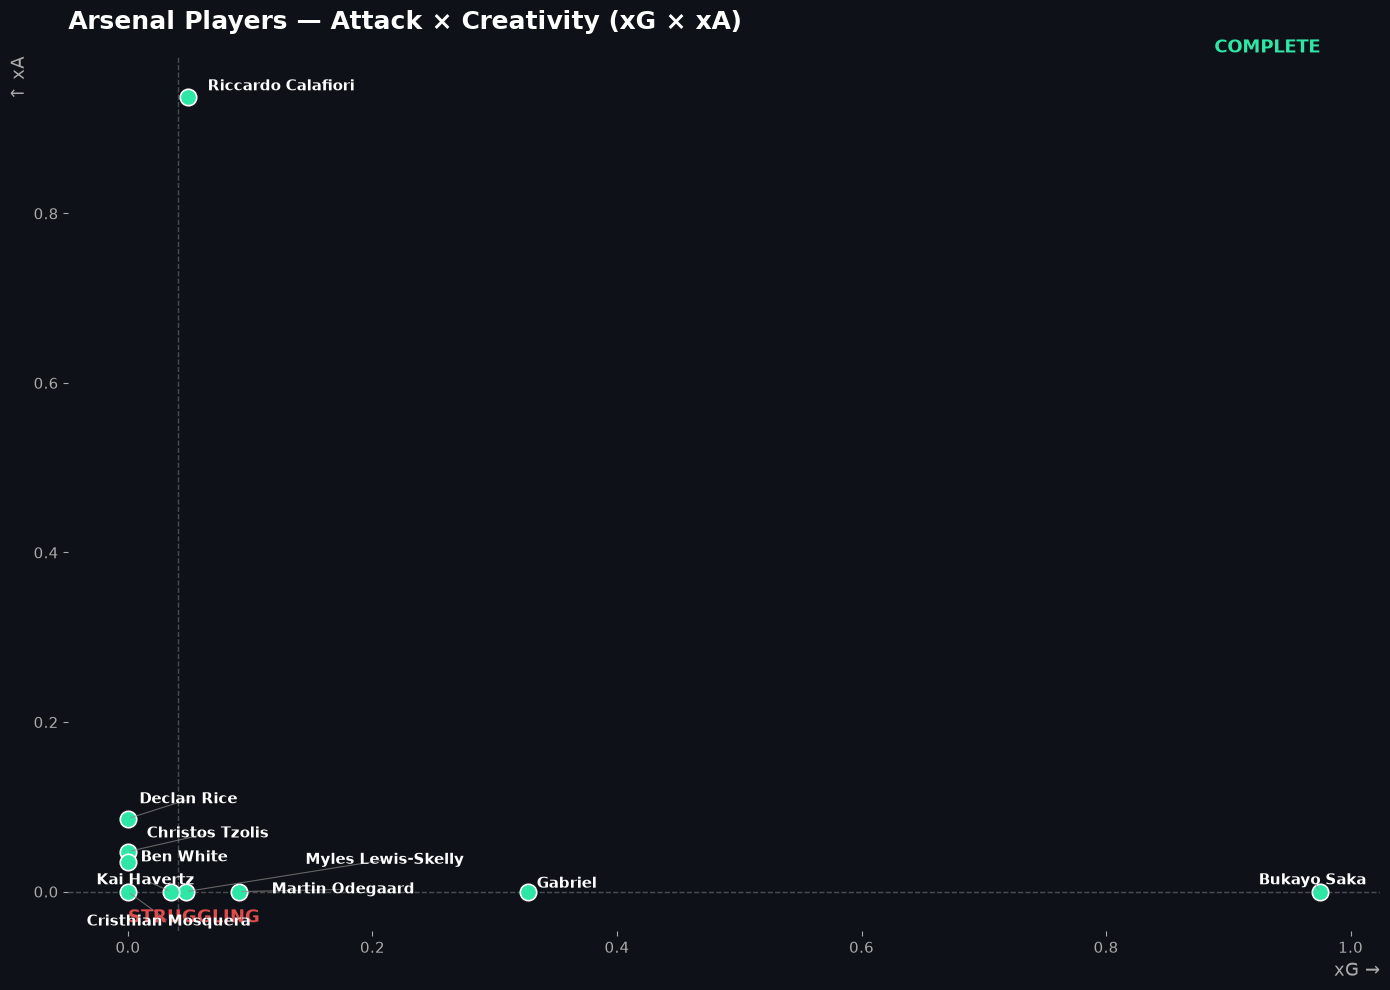

In [44]:


x_col, y_col = 'xG', 'xA'
x_vals = top_10[x_col].values
y_vals = top_10[y_col].values
players = top_10['player'].values

x_mid = np.median(x_vals)
y_mid = np.median(y_vals)

# --- Bigger figure ---
fig, ax = plt.subplots(figsize=(14, 10), facecolor="#0e1117")
ax.set_facecolor("#0e1117")

# --- Scatter points ---
ax.scatter(x_vals, y_vals, s=140, color="#2ee6a6", edgecolors="white",
           linewidths=1.2, zorder=3)

# --- Create text objects (no manual offset yet — adjustText will position them) ---
texts = []
for xi, yi, name in zip(x_vals, y_vals, players):
    texts.append(
        ax.text(xi, yi, name, fontsize=11, color="white", fontweight="bold", zorder=4)
    )

# --- Auto-adjust labels to avoid overlap, with connecting lines to their point ---
adjust_text(
    texts,
    ax=ax,
    arrowprops=dict(arrowstyle="-", color="#888888", lw=0.8, alpha=0.7),
    expand_points=(1.5, 1.5),
    force_text=(0.5, 0.7),
)

# --- Quadrant divider lines ---
ax.axvline(x_mid, color="white", linestyle="--", alpha=0.25, linewidth=1)
ax.axhline(y_mid, color="white", linestyle="--", alpha=0.25, linewidth=1)

# --- Quadrant labels ---
ax.text(max(x_vals), max(y_vals)*1.05, "COMPLETE", color="#2ee6a6",
        fontsize=13, fontweight="bold", ha="right", va="bottom")
ax.text(min(x_vals), min(y_vals)*0.9 - 0.02, "STRUGGLING", color="#e04b4b",
        fontsize=13, fontweight="bold", ha="left", va="top")

# --- Axis labels ---
ax.set_xlabel("xG →", color="#aaaaaa", fontsize=13, loc="right")
ax.set_ylabel("↑ xA", color="#aaaaaa", fontsize=13, loc="top")

# --- Styling ---
for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(colors="#aaaaaa", labelsize=11)
ax.set_title("Arsenal Players — Attack × Creativity (xG × xA)",
             color="white", fontsize=18, fontweight="bold", loc="left", pad=20)

plt.tight_layout()
plt.show()

<details open>
<summary><h2> Attack vs. Creativity (xG × xA) Insights</h2></summary>

| Player Quadrant | Key Players | Quadrant Breakdown |
| :--- | :--- | :--- |
| **High Creativity / Low Threat** | **Riccardo Calafiori** | Stands completely isolated at top-left (~0.94 xA, ~0.05 xG) as the sole elite provider. |
| **High Threat / Low Creativity** | **Bukayo Saka** | Far right outlier (~0.98 xG, 0.00 xA) representing the team's primary finisher. |
| **Moderate Threat** | **Gabriel** | Sits in isolation at ~0.33 xG, acting as the secondary aerial/set-piece threat. |
| **Low Threat & Low Creativity** | **Ødegaard, Havertz, Rice, White, etc.** | Clustered tightly in the bottom-left "Struggling" zone (near 0.0 xG and 0.0 xA). |

---

###  Key Takeaways

1. **Extreme Polarization:** Arsenal’s offensive engine was divided into two isolated extremes: Calafiori created nearly all dangerous chances, while Saka registered nearly all direct threat.
2. **Central Engine Shutdown:** Primary central playmakers like **Martin Ødegaard** and **Kai Havertz** were completely neutralized in the bottom-left quadrant.

<blockquote>
<b>Match Dynamic:</b> The scatter plot highlights a complete dependency on two individual channels: Calafiori generating from wide/deep areas and Saka executing on the end of plays, with zero central involvement.
</blockquote>

</details>

Who was the biggest goal threat?

In [45]:
df["xG_overperformance"] = df["goals"] - df["xG"]

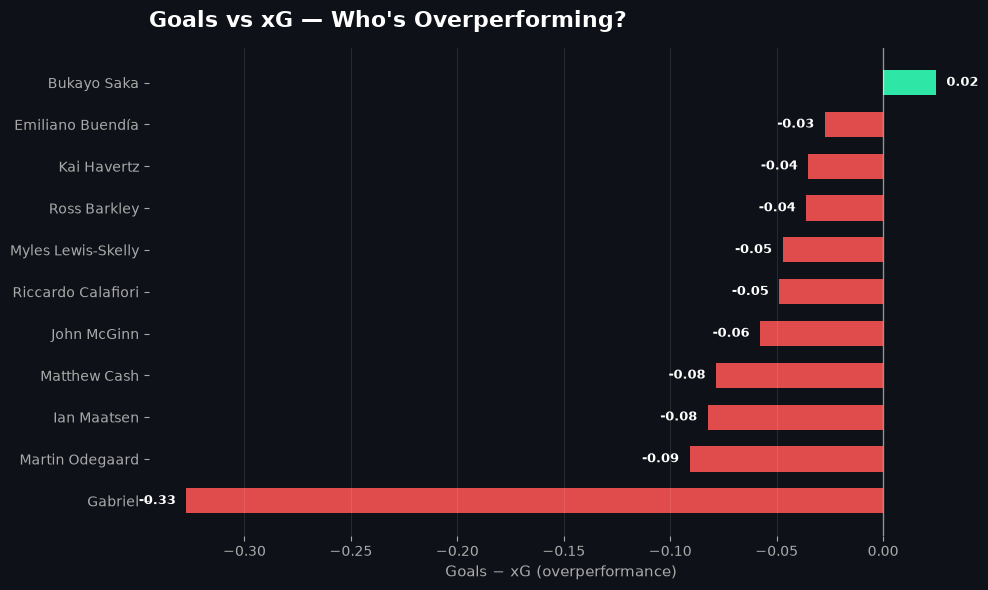

In [46]:

# Sort so biggest overperformers are at top
plot_df = df[df["xG_overperformance"] != 0].sort_values("xG_overperformance", ascending=True)
# Optional: limit to top N (e.g. top 15 by absolute over/underperformance)
# plot_df = df.reindex(df["xG_overperformance"].abs().sort_values(ascending=False).index).head(15)
# plot_df = plot_df.sort_values("xG_overperformance", ascending=True)

colors = ["#2ee6a6" if v >= 0 else "#e04b4b" for v in plot_df["xG_overperformance"]]

fig, ax = plt.subplots(figsize=(10, max(6, len(plot_df) * 0.35)), facecolor="#0e1117")
ax.set_facecolor("#0e1117")

bars = ax.barh(plot_df["player"], plot_df["xG_overperformance"], color=colors, height=0.6)

# Zero line for reference
ax.axvline(0, color="white", linewidth=1, alpha=0.5)

# Value labels at the end of each bar
for bar, val in zip(bars, plot_df["xG_overperformance"]):
    ax.text(
        val + (0.005 if val >= 0 else -0.005),
        bar.get_y() + bar.get_height() / 2,
        f"{val:.2f}",
        va="center",
        ha="left" if val >= 0 else "right",
        color="white",
        fontsize=9,
        fontweight="bold"
    )

# Styling
ax.set_title("Goals vs xG — Who's Overperforming?", color="white", 
             fontsize=16, fontweight="bold", loc="left", pad=15)
ax.set_xlabel("Goals − xG (overperformance)", color="#aaaaaa", fontsize=11)
ax.tick_params(colors="#aaaaaa", labelsize=10)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.grid(axis="x", color="white", alpha=0.1)

plt.tight_layout()
plt.show()

<details open>
<summary><h2> Goals vs. xG Finishing Efficiency Insights</h2></summary>

| Category | Player(s) | Value (Goals - xG) | Performance Breakdown |
| :--- | :--- | :---: | :--- |
| **Sole Overperformer** | **Bukayo Saka** | **+0.02** | The only player to outperform expectations, converting slightly above his expected goal tally. |
| **Minor Underperformers** | **Buendía, Havertz, Barkley, Lewis-Skelly, Calafiori** | **-0.03 to -0.05** | Slightly wasteful or restricted by low-xG chance quality. |
| **Moderate Underperformers** | **McGinn, Cash, Maatsen, Ødegaard** | **-0.06 to -0.09** | Failed to convert moderate chances, performing under expected returns. |
| **Major Underperformer** | **Gabriel** | **-0.33** | The biggest waste in front of goal, missing significant chance quality (0.33 xG with 0 goals). |

---

###  Key Takeaways

1. **Widespread Finishing Deficit:** 10 out of the 11 players analyzed underperformed their expected goals, showing a collective lack of clinical finishing across both teams.
2. **Gabriel's Missed Opportunity:** Gabriel represents the single largest negative delta (-0.33), highlighting a key missed set-piece or high-value chance.
3. **Saka's Precision:** Bukayo Saka stands completely alone in green (+0.02), underlining his status as the most lethal, reliable finisher on the pitch.

<blockquote>
<b>Finishing Summary:</b> Poor clinical execution dominated the match, with virtually every player failing to exceed their expected goals except Bukayo Saka.
</blockquote>

</details>

In [47]:
top_10

,id,goals,own_goals,shots,xG,time,player_id,team_id,position,player,h_a,yellow_card,red_card,roster_in,roster_out,key_passes,assists,xA,xGChain,xGBuildup,positionOrder,xGI,image_path
19,798284,0,0,1,0.048702,90,8129,83,DL,Riccardo Calafiori,a,0,0,0,0,1,1,0.937799,0.937799,0.000000,4,0.986501,images\Riccardo Calafiori.jpg
22,798287,1,0,2,0.975281,90,7322,83,AMR,Bukayo Saka,a,0,0,0,0,0,0,0.000000,1.010361,0.072562,11,0.975281,images\Bukayo Saka.jpg
18,798282,0,0,1,0.327258,90,5613,83,DC,Gabriel,a,0,0,0,0,0,0,0.000000,0.975281,0.975281,3,0.327258,images\Gabriel.jpg
23,798288,0,0,1,0.090885,72,2517,83,AMC,Martin Odegaard,a,0,0,798292,0,0,0,0.000000,0.037483,0.037483,12,0.090885,images\Martin Odegaard.jpg
20,798285,0,0,0,0.000000,86,5553,83,DMC,Declan Rice,a,0,0,798293,0,2,0,0.086185,0.975281,0.937799,7,0.086185,images\Declan Rice.jpg
21,798286,0,0,1,0.047201,72,12272,83,DMC,Myles Lewis-Skelly,a,0,0,798291,0,0,0,0.000000,1.022483,0.975281,7,0.047201,images\Myles Lewis-Skelly.jpg
24,798289,0,0,0,0.000000,47,9746,83,AML,Christos Tzolis,a,1,0,798294,0,1,0,0.047201,0.047201,0.000000,13,0.047201,images\Christos Tzolis.jpg
16,798281,0,0,0,0.000000,90,7298,83,DR,Ben White,a,0,0,0,0,1,0,0.035079,0.972878,0.937799,2,0.035079,images\Ben White.jpg
25,798290,0,0,1,0.035079,90,5220,83,FW,Kai Havertz,a,0,0,0,0,0,0,0.000000,0.972878,0.937799,15,0.035079,images\Kai Havertz.jpg
17,798283,0,0,0,0.000000,80,10024,83,DC,Cristhian Mosquera,a,0,0,798295,0,0,0,0.000000,0.937799,0.937799,3,0.000000,images\Cristhian Mosquera.jpg


Who created the best chances?

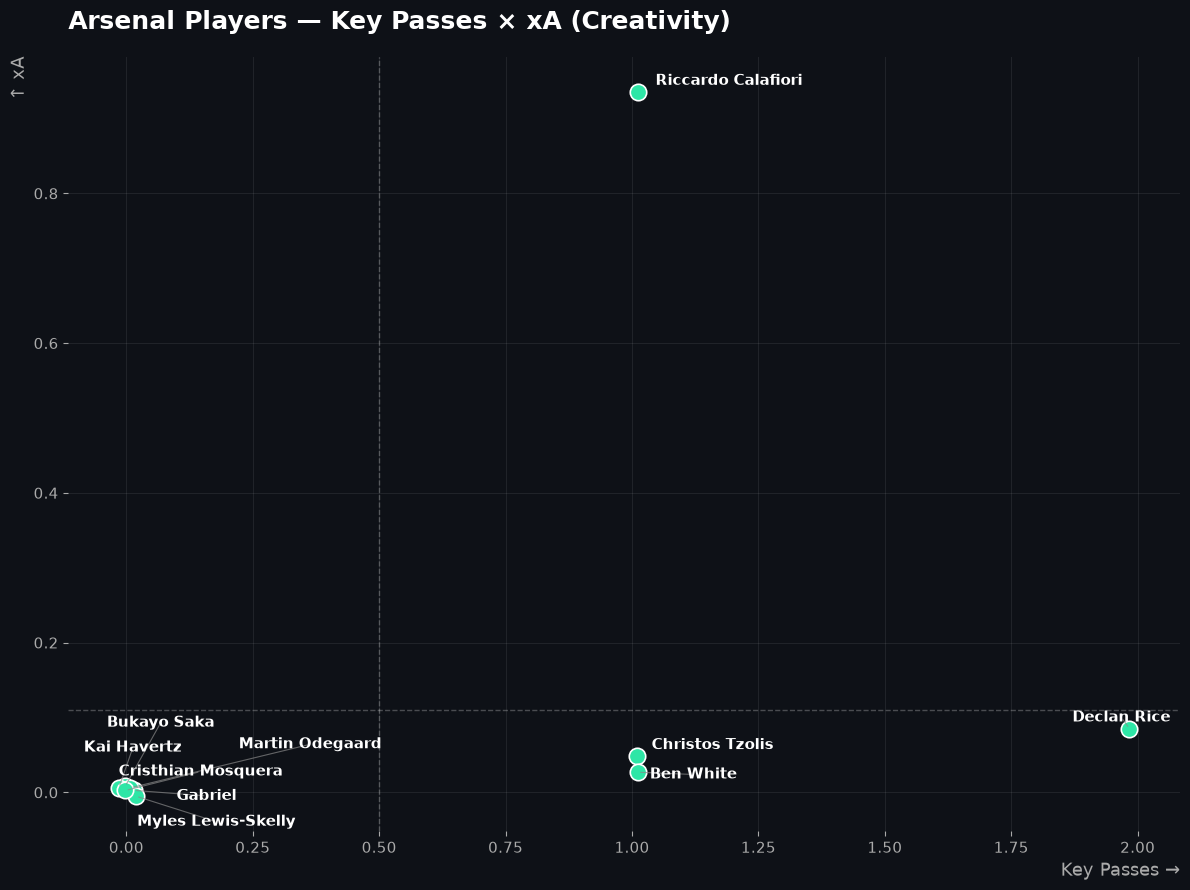

In [48]:


x_col, y_col = 'key_passes', 'xA'
x_vals = top_10[x_col].values.astype(float)
y_vals = top_10[y_col].values.astype(float)
players = top_10['player'].values

# --- Add tiny jitter so identical (0,0) points don't sit exactly on top of each other ---
rng = np.random.default_rng(42)  # fixed seed so it's reproducible
jitter_strength_x = (x_vals.max() - x_vals.min()) * 0.01 or 0.01
jitter_strength_y = (y_vals.max() - y_vals.min()) * 0.01 or 0.01
x_vals_jittered = x_vals + rng.uniform(-jitter_strength_x, jitter_strength_x, size=len(x_vals))
y_vals_jittered = y_vals + rng.uniform(-jitter_strength_y, jitter_strength_y, size=len(y_vals))

fig, ax = plt.subplots(figsize=(12, 9), facecolor="#0e1117")
ax.set_facecolor("#0e1117")

# --- Scatter points (use jittered positions) ---
ax.scatter(x_vals_jittered, y_vals_jittered, s=140, color="#2ee6a6", edgecolors="white",
           linewidths=1.2, zorder=3)

# --- Player name labels ---
texts = []
for xi, yi, name in zip(x_vals_jittered, y_vals_jittered, players):
    texts.append(
        ax.text(xi, yi, name, fontsize=11, color="white", fontweight="bold", zorder=4)
    )

# --- Auto-adjust: now also passing x/y so it knows to avoid the actual points too ---
adjust_text(
    texts,
    x=x_vals_jittered,
    y=y_vals_jittered,
    ax=ax,
    arrowprops=dict(arrowstyle="-", color="#888888", lw=0.8, alpha=0.7),
    expand_points=(2.0, 2.0),
    expand_text=(1.2, 1.2),
    force_text=(0.8, 1.0),
    force_points=(0.5, 0.5),
)

# --- Reference lines at the mean (use original, non-jittered values) ---
ax.axvline(np.mean(x_vals), color="white", linestyle="--", alpha=0.25, linewidth=1)
ax.axhline(np.mean(y_vals), color="white", linestyle="--", alpha=0.25, linewidth=1)

# --- Axis labels ---
ax.set_xlabel("Key Passes →", color="#aaaaaa", fontsize=13, loc="right")
ax.set_ylabel("↑ xA", color="#aaaaaa", fontsize=13, loc="top")

# --- Styling ---
for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(colors="#aaaaaa", labelsize=11)
ax.set_title("Arsenal Players — Key Passes × xA (Creativity)",
             color="white", fontsize=18, fontweight="bold", loc="left", pad=20)
ax.grid(color="white", alpha=0.08)

plt.tight_layout()
plt.show()

<details open>
<summary><h2> Key Passes vs. xA (Creativity Breakdown) Insights</h2></summary>

| Player Category | Key Players | Performance Breakdown |
| :--- | :--- | :--- |
| **High Quality / High Value** | **Riccardo Calafiori** | **1 Key Pass, ~0.94 xA:** Created an extraordinarily high-probability chance from a single pass. |
| **High Volume / Low Quality** | **Declan Rice** | **2 Key Passes, ~0.09 xA:** Led in key pass quantity, but the resulting attempts were low-value opportunities. |
| **Moderate Volume** | **Christos Tzolis, Ben White** | **1 Key Pass each (~0.04-0.05 xA):** Made minor, low-threat passing contributions. |
| **Low Activity Zone** | **Saka, Ødegaard, Havertz, Gabriel, etc.** | **0 Key Passes (~0.00 xA):** Clustered near the origin with zero direct chance creation. |

---

###  Key Takeaways

1. **Quality over Quantity:** While **Declan Rice** attempted the most key passes (2), **Riccardo Calafiori** delivered by far the most threat (~0.94 xA on 1 pass), proving quality trumps volume.
2. **Playmaking Isolation:** Arsenal struggled for collective creativity—only 4 players registered a key pass, while primary hubs like **Martin Ødegaard** and **Bukayo Saka** generated zero.

<blockquote>
<b>Creativity Summary:</b> Calafiori provided almost the entirety of Arsenal's high-value chance creation with one elite pass, while the rest of the team failed to generate significant threat.
</blockquote>

</details>

Who was most involved in dangerous attacks?

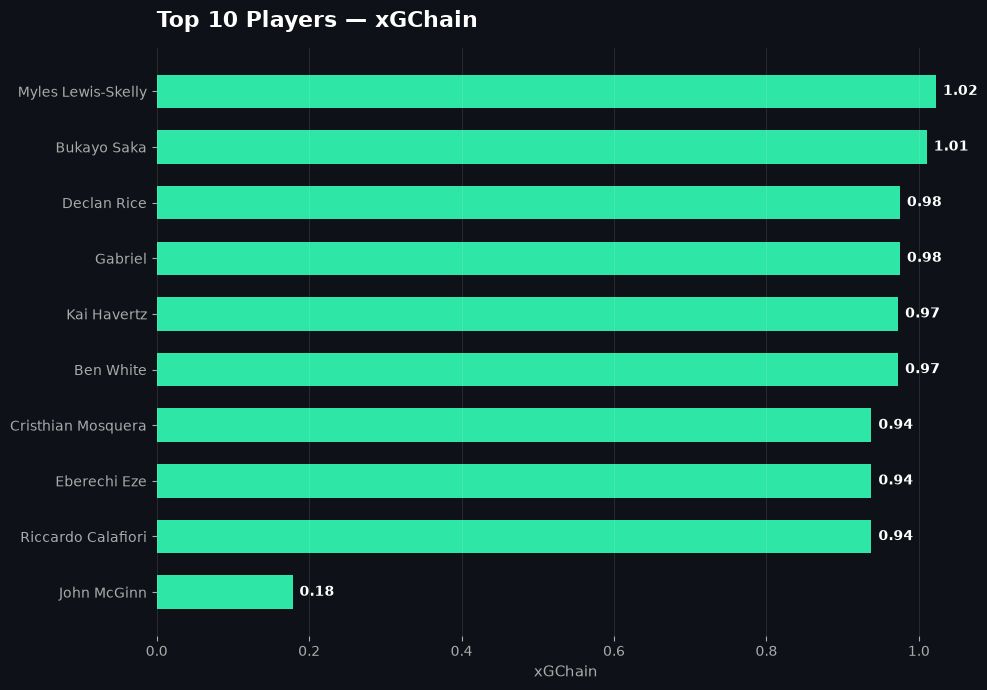

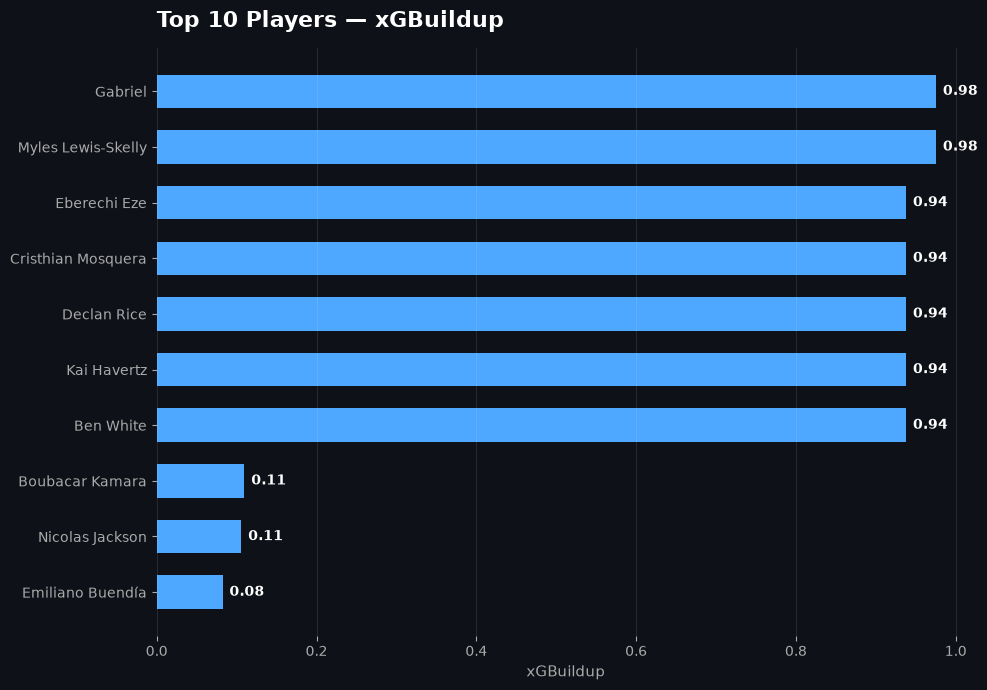

In [49]:

def plot_top10_bar(df, col, title, color="#2ee6a6"):
    plot_df = df.sort_values(col, ascending=False).head(10)
    plot_df = plot_df.sort_values(col, ascending=True)  # so biggest ends up on top visually

    fig, ax = plt.subplots(figsize=(10, 7), facecolor="#0e1117")
    ax.set_facecolor("#0e1117")

    bars = ax.barh(plot_df["player"], plot_df[col], color=color, height=0.6)

    # Value labels at the end of each bar
    for bar, val in zip(bars, plot_df[col]):
        ax.annotate(
            f"{val:.2f}",
            xy=(val, bar.get_y() + bar.get_height() / 2),
            xytext=(5, 0),
            textcoords="offset points",
            va="center",
            ha="left",
            color="white",
            fontsize=10,
            fontweight="bold"
        )

    ax.set_title(title, color="white", fontsize=16, fontweight="bold", loc="left", pad=15)
    ax.set_xlabel(col, color="#aaaaaa", fontsize=11)
    ax.tick_params(colors="#aaaaaa", labelsize=10)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.grid(axis="x", color="white", alpha=0.1)

    plt.tight_layout()
    plt.show()

# --- xGChain ---
plot_top10_bar(df, "xGChain", "Top 10 Players — xGChain", color="#2ee6a6")

# --- xGBuildup ---
plot_top10_bar(df, "xGBuildup", "Top 10 Players — xGBuildup", color="#4ea8ff")

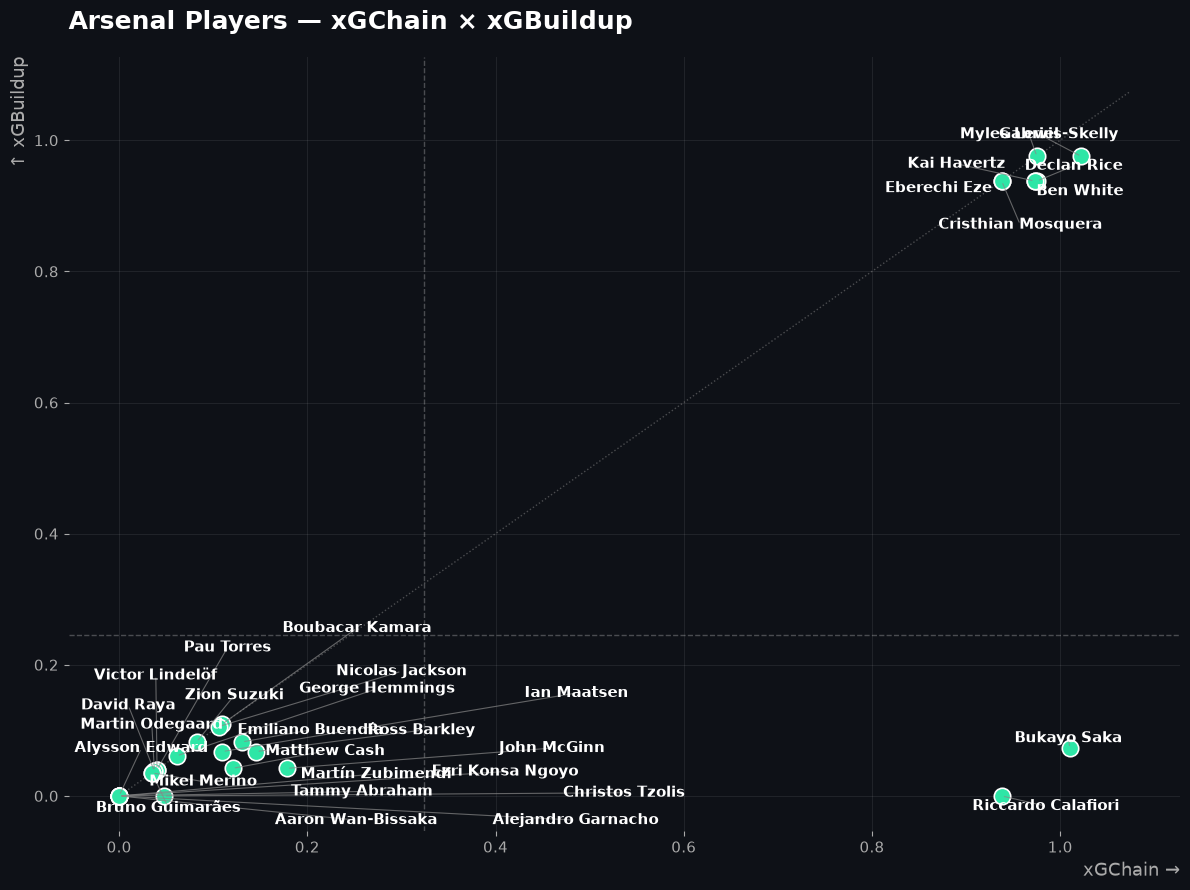

In [50]:


x_col, y_col = 'xGChain', 'xGBuildup'
x_vals = df[x_col].values
y_vals = df[y_col].values
players = df['player'].values

fig, ax = plt.subplots(figsize=(12, 9), facecolor="#0e1117")
ax.set_facecolor("#0e1117")

# --- Scatter points ---
ax.scatter(x_vals, y_vals, s=140, color="#2ee6a6", edgecolors="white",
           linewidths=1.2, zorder=3)

# --- Player name labels ---
texts = []
for xi, yi, name in zip(x_vals, y_vals, players):
    texts.append(
        ax.text(xi, yi, name, fontsize=11, color="white", fontweight="bold", zorder=4)
    )

# --- Auto-adjust to avoid overlapping labels ---
adjust_text(
    texts,
    ax=ax,
    arrowprops=dict(arrowstyle="-", color="#888888", lw=0.8, alpha=0.7),
    expand_points=(1.5, 1.5),
    force_text=(0.5, 0.7),
)

# --- Reference lines at the mean ---
ax.axvline(np.mean(x_vals), color="white", linestyle="--", alpha=0.25, linewidth=1)
ax.axhline(np.mean(y_vals), color="white", linestyle="--", alpha=0.25, linewidth=1)

# --- Diagonal reference line (xGChain == xGBuildup) ---
lims = [0, max(x_vals.max(), y_vals.max()) * 1.05]
ax.plot(lims, lims, color="#888888", linestyle=":", linewidth=1, alpha=0.5)

# --- Axis labels ---
ax.set_xlabel("xGChain →", color="#aaaaaa", fontsize=13, loc="right")
ax.set_ylabel("↑ xGBuildup", color="#aaaaaa", fontsize=13, loc="top")

# --- Styling ---
for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(colors="#aaaaaa", labelsize=11)
ax.set_title("Arsenal Players — xGChain × xGBuildup",
             color="white", fontsize=18, fontweight="bold", loc="left", pad=20)
ax.grid(color="white", alpha=0.08)

plt.tight_layout()
plt.show()

<details open>
<summary><h2> Possession Involvement (xGChain × xGBuildup) Insights</h2></summary>

| Player Category | Key Players | Role Breakdown |
| :--- | :--- | :--- |
| **Complete Build-Up Hubs** | **Declan Rice, Ben White, Kai Havertz, Gabriel, Myles Lewis-Skelly, Eberechi Eze, Cristhian Mosquera** | **High xGChain (~0.9–1.0) & High xGBuildup (~0.9–1.0):** Central orchestrators who initiated and sustained possession phases leading to shots without necessarily taking the final shot. |
| **Pure Finishers / Final Outlets** | **Bukayo Saka, Riccardo Calafiori** | **High xGChain (~0.95–1.0) & Low xGBuildup (~0.0–0.1):** Almost exclusively involved in the terminal phase (shots/key passes) rather than early build-up play. |
| **Low Phase-Involvement** | **Martin Ødegaard, David Raya, Christos Tzolis, Mikel Merino, etc.** | **Low xGChain (<0.2) & Low xGBuildup (<0.2):** Clustered near the origin with minimal involvement in overall possession sequences leading to chances. |

---

###  Key Takeaways

1. **Clear Tactical Division:** Arsenal's build-up shows two clear functional profiles—a large core group facilitating progression from deep (top-right) and an isolated duo (**Saka** and **Calafiori**) receiving the ball strictly to execute final actions (bottom-right).
2. **Central Build-Up Engine:** The heavy cluster of defensive and midfield players in the top-right highlights strong collective involvement during early progression before recycling play wide.

<blockquote>
<b>Possession Summary:</b> The squad maintained a healthy structural split: a reliable 7-player core sustained build-up progression, while Saka and Calafiori operated purely as high-value end products.
</blockquote>

</details>

In [51]:
arsenal["xG90"] = arsenal["xG"] / arsenal["time"] * 90
arsenal["xA90"] = arsenal["xA"] / arsenal["time"] * 90
arsenal["shots90"] = arsenal["shots"] / arsenal["time"] * 90
arsenal["key_passes90"] = arsenal["key_passes"] / arsenal["time"] * 90

In [52]:
# Create rank columns (1 = best) for each per-90 metric
rank_cols = ["xG90", "xA90", "shots90", "key_passes90"]

for col in rank_cols:
    arsenal[f"{col}_rank"] = arsenal[col].rank(ascending=False, method="min").astype(int)

# View player + all metrics + all ranks together
display_cols = ["player"] + rank_cols + [f"{c}_rank" for c in rank_cols]
arsenal[display_cols].sort_values("xG90_rank")

,player,xG90,xA90,shots90,key_passes90,xG90_rank,xA90_rank,shots90_rank,key_passes90_rank
22,Bukayo Saka,0.975281,0.000000,2.00,0.000000,1,5,1,5
18,Gabriel,0.327258,0.000000,1.00,0.000000,2,5,4,5
23,Martin Odegaard,0.113606,0.000000,1.25,0.000000,3,5,2,5
21,Myles Lewis-Skelly,0.059002,0.000000,1.25,0.000000,4,5,2,5
19,Riccardo Calafiori,0.048702,0.937799,1.00,1.000000,5,1,4,3
25,Kai Havertz,0.035079,0.000000,1.00,0.000000,6,5,4,5
17,Cristhian Mosquera,0.000000,0.000000,0.00,0.000000,7,5,7,5
16,Ben White,0.000000,0.035079,0.00,1.000000,7,4,7,3
20,Declan Rice,0.000000,0.090194,0.00,2.093023,7,3,7,1
15,David Raya,0.000000,0.000000,0.00,0.000000,7,5,7,5


In [53]:
qualified = arsenal[arsenal["time"] >= 90]  # e.g. 5 full matches worth of minutes
for col in rank_cols:
    qualified[f"{col}_rank"] = qualified[col].rank(ascending=False, method="min").astype(int)

In [54]:
qualified 

,id,goals,own_goals,shots,xG,time,player_id,team_id,position,player,h_a,yellow_card,red_card,roster_in,roster_out,key_passes,assists,xA,xGChain,xGBuildup,positionOrder,xGI,xG90,xA90,shots90,key_passes90,xG90_rank,xA90_rank,shots90_rank,key_passes90_rank
15,798280,0,0,0,0.000000,90,9676,83,GK,David Raya,a,0,0,0,0,0,0,0.000000,0.037483,0.037483,1,0.000000,0.000000,0.000000,0.0,0.0,5,3,5,3
16,798281,0,0,0,0.000000,90,7298,83,DR,Ben White,a,0,0,0,0,1,0,0.035079,0.972878,0.937799,2,0.035079,0.000000,0.035079,0.0,1.0,5,2,5,1
18,798282,0,0,1,0.327258,90,5613,83,DC,Gabriel,a,0,0,0,0,0,0,0.000000,0.975281,0.975281,3,0.327258,0.327258,0.000000,1.0,0.0,2,3,2,3
19,798284,0,0,1,0.048702,90,8129,83,DL,Riccardo Calafiori,a,0,0,0,0,1,1,0.937799,0.937799,0.000000,4,0.986501,0.048702,0.937799,1.0,1.0,3,1,2,1
22,798287,1,0,2,0.975281,90,7322,83,AMR,Bukayo Saka,a,0,0,0,0,0,0,0.000000,1.010361,0.072562,11,0.975281,0.975281,0.000000,2.0,0.0,1,3,1,3
25,798290,0,0,1,0.035079,90,5220,83,FW,Kai Havertz,a,0,0,0,0,0,0,0.000000,0.972878,0.937799,15,0.035079,0.035079,0.000000,1.0,0.0,4,3,2,3


Does playing more minutes necessarily mean greater attacking contribution?

In [55]:
arsenal["xGI"] = arsenal["xG"] + arsenal["xA"]

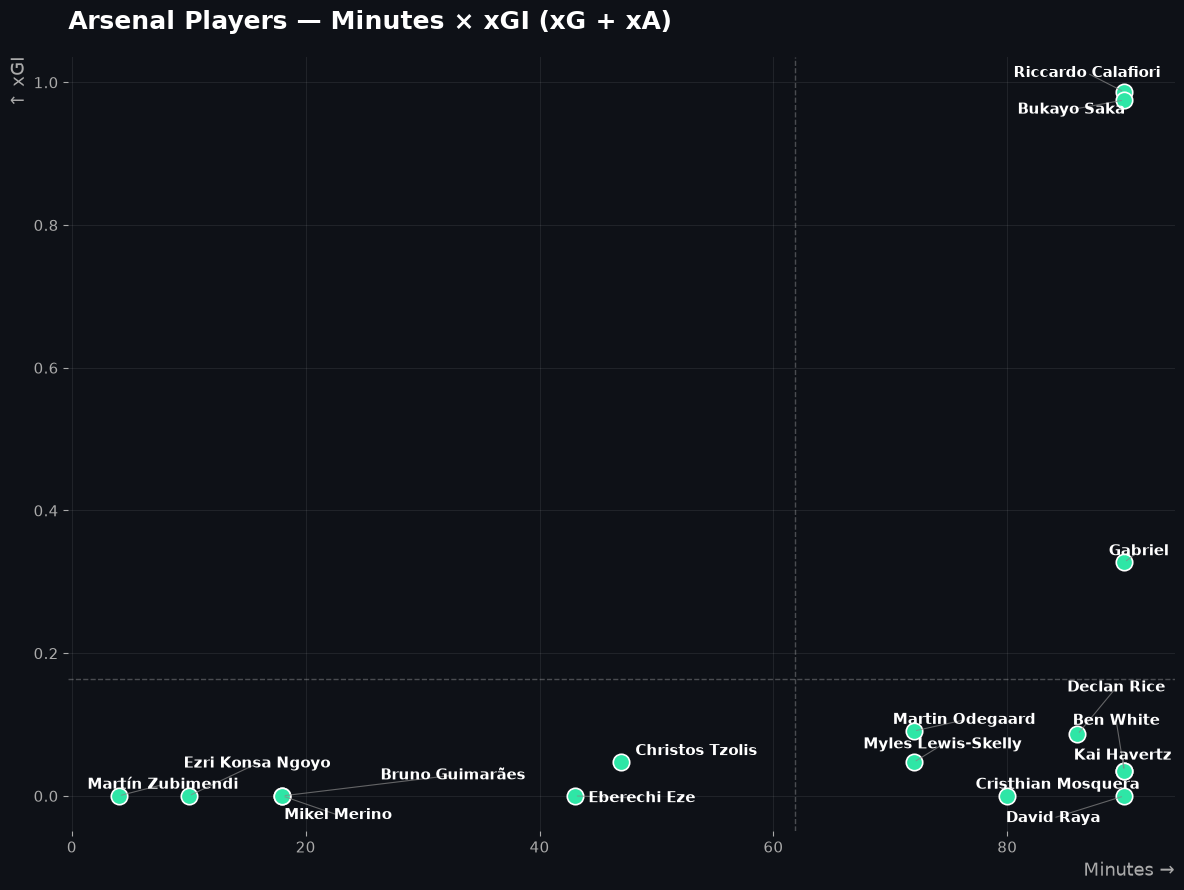

In [56]:


x_col, y_col = 'time', 'xGI'
x_vals = arsenal[x_col].values
y_vals = arsenal[y_col].values
players = arsenal['player'].values

fig, ax = plt.subplots(figsize=(12, 9), facecolor="#0e1117")
ax.set_facecolor("#0e1117")

# --- Scatter points ---
ax.scatter(x_vals, y_vals, s=140, color="#2ee6a6", edgecolors="white",
           linewidths=1.2, zorder=3)

# --- Player name labels ---
texts = []
for xi, yi, name in zip(x_vals, y_vals, players):
    texts.append(
        ax.text(xi, yi, name, fontsize=11, color="white", fontweight="bold", zorder=4)
    )

# --- Auto-adjust to avoid overlapping labels ---
adjust_text(
    texts,
    ax=ax,
    arrowprops=dict(arrowstyle="-", color="#888888", lw=0.8, alpha=0.7),
    expand_points=(1.5, 1.5),
    force_text=(0.5, 0.7),
)

# --- Reference lines at the mean ---
ax.axvline(np.mean(x_vals), color="white", linestyle="--", alpha=0.25, linewidth=1)
ax.axhline(np.mean(y_vals), color="white", linestyle="--", alpha=0.25, linewidth=1)

# --- Axis labels ---
ax.set_xlabel("Minutes →", color="#aaaaaa", fontsize=13, loc="right")
ax.set_ylabel("↑ xGI", color="#aaaaaa", fontsize=13, loc="top")

# --- Styling ---
for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(colors="#aaaaaa", labelsize=11)
ax.set_title("Arsenal Players — Minutes × xGI (xG + xA)",
             color="white", fontsize=18, fontweight="bold", loc="left", pad=20)
ax.grid(color="white", alpha=0.08)

plt.tight_layout()
plt.show()

<details open>
<summary><h2>⏱ Minutes vs. xGI (Expected Goal Involvement) Insights</h2></summary>

| Player Category | Key Players | Performance Breakdown |
| :--- | :--- | :--- |
| **Elite Efficiency / High Minutes** | **Riccardo Calafiori, Bukayo Saka** | **~90 Mins, ~0.98–0.99 xGI:** Maximized full match duration to generate elite attacking and playmaking threat. |
| **Moderate Impact / High Minutes** | **Gabriel** | **~90 Mins, ~0.33 xGI:** Maintained solid set-piece/goal involvement over full regular minutes. |
| **Low xGI Workhorses** | **Rice, White, Havertz, Ødegaard, Lewis-Skelly, Mosquera, Raya** | **~70–90 Mins, <0.10 xGI:** Played high minutes but registered minimal direct expected goal or assist contributions. |
| **Low Minutes / Sub Outlets** | **Tzolis, Eze, Merino, Guimarães, Konsa, Zubimendi** | **<50 Mins, ~0.00–0.05 xGI:** Came on as rotations/substitutes with limited impact on final goal actions. |

---

###  Key Takeaways

1. **Volume Driven Production:** **Saka** and **Calafiori** were given full match workloads (~90 mins) and delivered nearly 1.0 xGI each, standing far above all other starters.
2. **Workload vs. Output Disconnect:** Key starters like **Kai Havertz**, **Martin Ødegaard**, and **Declan Rice** logged heavy minutes (~70–90 mins) but generated under 0.10 xGI, showing low direct threat despite high playing time.

<blockquote>
<b>Workload Summary:</b> Arsenal relied heavily on Saka and Calafiori to convert high minutes into goal threat, while the rest of the starting XI primarily served structural roles without adding xGI volume.
</blockquote>

</details>

Did Arsenal's substitutions improve their attacking output?

In [57]:
# 1. Filter for players who went out and players who came in
# (Assuming roster_out and roster_in contain the substitution minute or a valid flag)
subs_out = arsenal[arsenal['roster_out'].notna() & (arsenal['roster_out'] != 0)].copy()
subs_in = arsenal[arsenal['roster_in'].notna() & (arsenal['roster_in'] != 0)].copy()

In [58]:
substitution_pairs = pd.merge(
    subs_out,
    subs_in,
    left_on=[ 'roster_out',"id"],
    right_on=['id', 'roster_in'],
    #suffixes=('_out', '_in')
)

In [59]:

# 1. Filter for players who went out and players who came in
# (Assuming roster_out and roster_in contain the substitution minute or a valid flag)
subs_out = arsenal[arsenal['roster_out'].notna() & (arsenal['roster_out'] != 0)].copy()
subs_in = arsenal[arsenal['roster_in'].notna() & (arsenal['roster_in'] != 0)].copy()

# 2. Merge the incoming and outgoing players by match and team
# Note: Add 'match_id' to your merge keys if it's available in your full dataset
substitution_pairs = pd.merge(
    subs_out,
    subs_in,
    left_on=[ 'roster_out',"id"],
    right_on=['id', 'roster_in'],
    suffixes=('_out', '_in')
)

# 3. Calculate differences for key metrics
substitution_pairs['xG_diff'] = substitution_pairs['xG_in'] - substitution_pairs['xG_out']
substitution_pairs['xA_diff'] = substitution_pairs['xA_in'] - substitution_pairs['xA_out']
substitution_pairs['shots_diff'] = substitution_pairs['shots_in'] - substitution_pairs['shots_out']

# 4. View summary of comparisons
comparison_summary = substitution_pairs[[
    'player_out', 'player_in', 'xG_out', 'xG_in', 'xG_diff', 'xA_diff', 'shots_diff'
]]

print(comparison_summary.head())


         player_out           player_in  xG_out     xG_in   xG_diff   xA_diff  \
0   Bruno Guimarães  Myles Lewis-Skelly     0.0  0.047201  0.047201  0.000000   
1      Eberechi Eze     Christos Tzolis     0.0  0.000000  0.000000  0.047201   
2      Mikel Merino     Martin Odegaard     0.0  0.090885  0.090885  0.000000   
3  Ezri Konsa Ngoyo  Cristhian Mosquera     0.0  0.000000  0.000000  0.000000   
4  Martín Zubimendi         Declan Rice     0.0  0.000000  0.000000  0.086185   

   shots_diff  
0           1  
1           0  
2           1  
3           0  
4           0  


Where did Arsenal's attacking threat come from?

In [60]:
arsenal.groupby("position")[["xG", "xA", "shots", "key_passes"]].sum()

,xG,xA,shots,key_passes
position,,,,
AMC,0.090885,0.000000,1,0
AML,0.000000,0.047201,0,1
AMR,0.975281,0.000000,2,0
DC,0.327258,0.000000,1,0
DL,0.048702,0.937799,1,1
DMC,0.047201,0.086185,1,2
DR,0.000000,0.035079,0,1
FW,0.035079,0.000000,1,0
GK,0.000000,0.000000,0,0


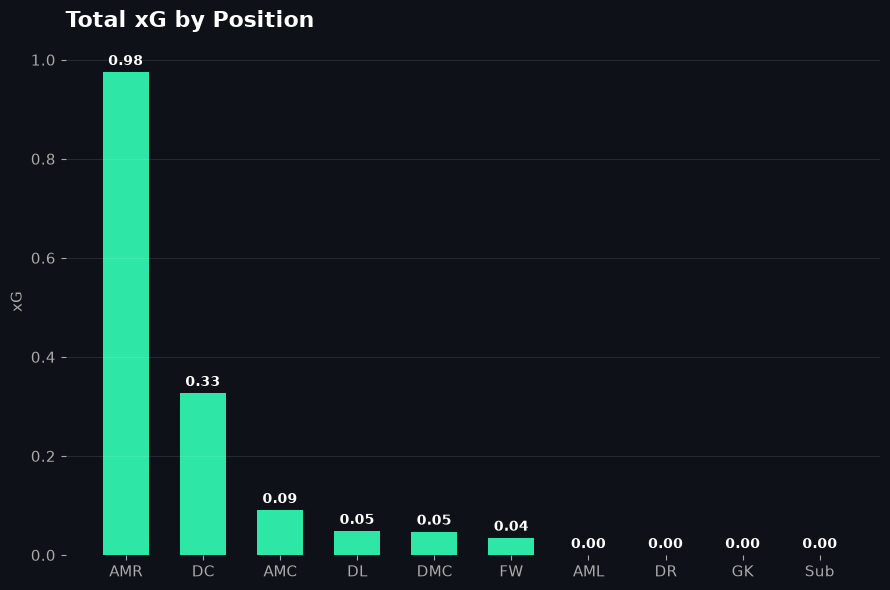

In [61]:

position_xg = arsenal.groupby("position")["xG"].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 6), facecolor="#0e1117")
ax.set_facecolor("#0e1117")

bars = ax.bar(position_xg.index, position_xg.values, color="#2ee6a6", width=0.6)

# Value labels on top of each bar
for bar, val in zip(bars, position_xg.values):
    ax.annotate(
        f"{val:.2f}",
        xy=(bar.get_x() + bar.get_width() / 2, val),
        xytext=(0, 5),
        textcoords="offset points",
        ha="center",
        color="white",
        fontsize=10,
        fontweight="bold"
    )

# Styling
ax.set_title("Total xG by Position", color="white", fontsize=16, fontweight="bold", loc="left", pad=15)
ax.set_ylabel("xG", color="#aaaaaa", fontsize=11)
ax.tick_params(colors="#aaaaaa", labelsize=11)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.grid(axis="y", color="white", alpha=0.1)

plt.tight_layout()
plt.show()

<details open>
<summary><h2> Total xG by Position Insights</h2></summary>

| Position Tier | Position Code | Total xG | Positional Contribution Breakdown |
| :--- | :---: | :---: | :--- |
| **Primary Scoring Hub** | **AMR** (Attacking Mid Right) | **0.98** | Generates virtually all goal threat (driven by Bukayo Saka on the right wing). |
| **Secondary Threat** | **DC** (Defender Central) | **0.33** | Strong secondary contribution, primarily coming from set-piece opportunities (Gabriel). |
| **Minor Contributions** | **AMC, DL, DMC, FW** | **0.04 – 0.09** | Minimal direct threat from central attacking midfield (0.09), left-back (0.05), defensive midfield (0.05), or forward (0.04). |
| **Zero Production** | **AML, DR, GK, Sub** | **0.00** | Zero expected goal contribution from the left wing, right-back, goalkeeper, or bench. |

---

###  Key Takeaways

1. **Extreme Right-Side Bias:** The **AMR position (0.98 xG)** accounts for the vast majority of total expected goals, showing a tactical reliance on the right flank to create shot opportunities.
2. **Forward Non-Factor:** The central **FW position generated just 0.04 xG**, illustrating how central attackers were starved of chances or kept away from dangerous scoring zones.

<blockquote>
<b>Positional Summary:</b> Goal creation was heavily asymmetric, funneling almost exclusively through the right winger (AMR) and set-piece central defender (DC), while all other positional roles provided negligible threat.
</blockquote>

</details>

In [62]:
arsenal["xG_per_shot"] = arsenal["xG"] / arsenal["shots"]

Plotting 6 of 16 players (dropped rows with missing/undefined xG_per_shot)


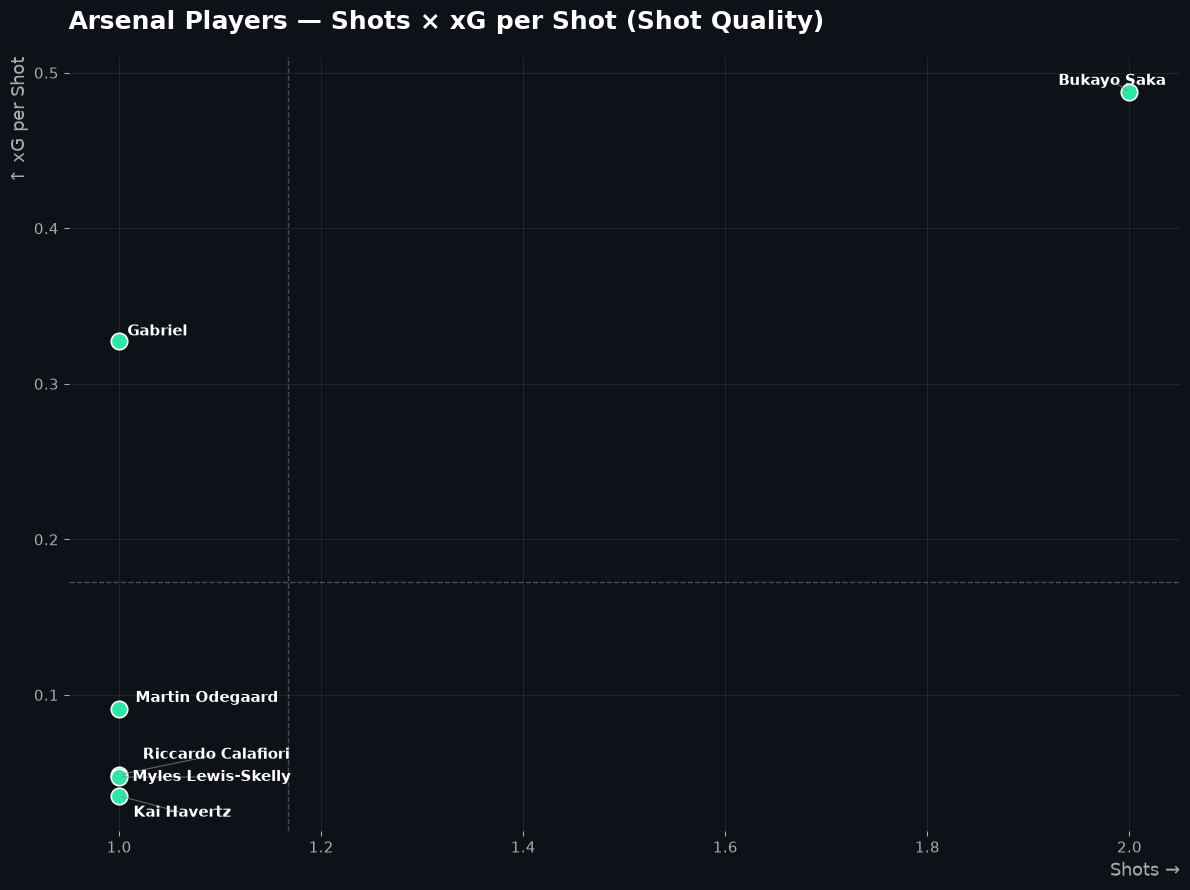

In [77]:


x_col, y_col = 'shots', 'xG_per_shot'

# Filter out rows with NaN or inf in either column (e.g. players with 0 shots)
plot_data = arsenal[[x_col, y_col, 'player']].replace([np.inf, -np.inf], np.nan).dropna(subset=[x_col, y_col])

x_vals = plot_data[x_col].values
y_vals = plot_data[y_col].values
players = plot_data['player'].values

print(f"Plotting {len(plot_data)} of {len(arsenal)} players (dropped rows with missing/undefined xG_per_shot)")

fig, ax = plt.subplots(figsize=(12, 9), facecolor="#0e1117")
ax.set_facecolor("#0e1117")

# --- Scatter points ---
ax.scatter(x_vals, y_vals, s=140, color="#2ee6a6", edgecolors="white",
           linewidths=1.2, zorder=3)

# --- Player name labels ---
texts = []
for xi, yi, name in zip(x_vals, y_vals, players):
    texts.append(
        ax.text(xi, yi, name, fontsize=11, color="white", fontweight="bold", zorder=4)
    )

# --- Auto-adjust, now also passing x/y so it avoids the actual points too ---
adjust_text(
    texts,
    x=x_vals,
    y=y_vals,
    ax=ax,
    arrowprops=dict(arrowstyle="-", color="#888888", lw=0.8, alpha=0.7),
    expand_points=(2.0, 2.0),
    expand_text=(1.2, 1.2),
    force_text=(0.8, 1.0),
    force_points=(0.5, 0.5),
)

# --- Reference lines at the mean ---
ax.axvline(np.mean(x_vals), color="white", linestyle="--", alpha=0.25, linewidth=1)
ax.axhline(np.mean(y_vals), color="white", linestyle="--", alpha=0.25, linewidth=1)

# --- Axis labels ---
ax.set_xlabel("Shots →", color="#aaaaaa", fontsize=13, loc="right")
ax.set_ylabel("↑ xG per Shot", color="#aaaaaa", fontsize=13, loc="top")

# --- Styling ---
for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(colors="#aaaaaa", labelsize=11)
ax.set_title("Arsenal Players — Shots × xG per Shot (Shot Quality)",
             color="white", fontsize=18, fontweight="bold", loc="left", pad=20)
ax.grid(color="white", alpha=0.08)

plt.tight_layout()
plt.show()

<details open>
<summary><b> Shots × xG per Shot (Shot Quality) Insights</b></summary>

| Player Quadrant | Key Players | Performance Breakdown |
| :--- | :--- | :--- |
| **High Volume / High Quality** | **Bukayo Saka** | **2 Shots, ~0.49 xG/shot:** Top-right outlier, combining the highest shot volume with elite-level chance conversion probability. |
| **Low Volume / High Quality** | **Gabriel** | **1 Shot, ~0.33 xG/shot:** High threat on a single set-piece/inside-box attempt. |
| **Low Volume / Low Quality** | **Ødegaard, Calafiori, Lewis-Skelly, Havertz** | **1 Shot each, <0.10 xG/shot:** Clustered in the bottom-left zone with low-probability attempts from distance or poor angles. |

---

**Key Takeaways**

* **Elite Individual Threat:** Bukayo Saka stands alone in the upper-right corner as the team's primary offensive driver, generating both volume and quality.
* **Low-Probability Attempts:** The majority of shooting players (Ødegaard, Calafiori, Lewis-Skelly, Havertz) were limited to single, low-value attempts under 0.10 xG/shot.

<blockquote>
<b>Shot Selection Summary:</b> Except for Bukayo Saka's high-probability opportunities and a solid chance for Gabriel, Arsenal struggled to manufacture high-value shot locations.
</blockquote>

</details>

In [64]:


match_id = "31199"

with UnderstatClient() as understat:
    # 1. Fetch Shot Data (xG, coordinates, player, situation, shotResult)
    shot_data = understat.match(match=match_id).get_shot_data()
    
    # 2. Fetch Roster / Player Data (stats, minutes played, rosters)
    roster_data = understat.match(match=match_id).get_roster_data()

# Convert home/away shots into a single Pandas DataFrame
home_shots = pd.DataFrame(shot_data['h'])
away_shots = pd.DataFrame(shot_data['a'])
all_shots = pd.concat([home_shots, away_shots], ignore_index=True)

print("--- Shots Data Sample ---")
print(all_shots[['minute', 'player','xG', 'result', 'shotType']].head())

--- Shots Data Sample ---
  minute            player                    xG       result   shotType
0      6       John McGinn  0.020744293928146362  MissedShots   LeftFoot
1     11  Emiliano Buendía   0.02737284079194069   ShotOnPost  RightFoot
2     26       Ian Maatsen   0.04204452782869339  MissedShots  RightFoot
3     46       Ian Maatsen    0.0402790792286396  MissedShots   LeftFoot
4     64      Matthew Cash   0.07843043655157089  BlockedShot   LeftFoot


In [65]:
away_shots

,id,minute,result,X,Y,xG,player,h_a,player_id,situation,season,shotType,match_id,h_team,a_team,h_goals,a_goals,date,player_assisted,lastAction
0,691697,7,BlockedShot,0.8440000152587891,0.665,0.04720120131969452,Myles Lewis-Skelly,a,12272,OpenPlay,2026,LeftFoot,31199,Aston Villa,Arsenal,0,1,2026-08-31 19:00:00,Christos Tzolis,Pass
1,691698,7,MissedShots,0.9359999847412109,0.4620000076293945,0.327258437871933,Gabriel,a,5613,FromCorner,2026,Head,31199,Aston Villa,Arsenal,0,1,2026-08-31 19:00:00,NaN,None
2,691700,12,MissedShots,0.8109999847412109,0.335,0.03748276084661484,Bukayo Saka,a,7322,OpenPlay,2026,LeftFoot,31199,Aston Villa,Arsenal,0,1,2026-08-31 19:00:00,Declan Rice,TakeOn
3,691701,17,MissedShots,0.9640000152587891,0.5770000076293945,0.04870227724313736,Riccardo Calafiori,a,8129,FromCorner,2026,Head,31199,Aston Villa,Arsenal,0,1,2026-08-31 19:00:00,Declan Rice,Aerial
4,691704,56,MissedShots,0.8159999847412109,0.3290000152587891,0.09088468551635742,Martin Odegaard,a,2517,DirectFreekick,2026,LeftFoot,31199,Aston Villa,Arsenal,0,1,2026-08-31 19:00:00,NaN,Standard
5,691705,58,Goal,0.975,0.49400001525878906,0.9377986788749695,Bukayo Saka,a,7322,OpenPlay,2026,RightFoot,31199,Aston Villa,Arsenal,0,1,2026-08-31 19:00:00,Riccardo Calafiori,Pass
6,691709,73,SavedShot,0.8390000152587891,0.26399999618530273,0.03507942706346512,Kai Havertz,a,5220,OpenPlay,2026,LeftFoot,31199,Aston Villa,Arsenal,0,1,2026-08-31 19:00:00,Ben White,Pass


In [66]:
away_shots.dtypes

id                 str
minute             str
result             str
X                  str
Y                  str
xG                 str
player             str
h_a                str
player_id          str
situation          str
season             str
shotType           str
match_id           str
h_team             str
a_team             str
h_goals            str
a_goals            str
date               str
player_assisted    str
lastAction         str
dtype: object

In [67]:
len(away_shots)

7

In [68]:
# 1. Float conversions (continuous coordinates and probabilistic values)
float_cols = ['X', 'Y', 'xG']
away_shots[float_cols] = away_shots[float_cols].apply(pd.to_numeric, errors='coerce')

# 2. Integer conversions (counts and identifiers)
int_cols = ['id', 'minute', 'player_id', 'season', 'match_id', 'h_goals', 'a_goals']
away_shots[int_cols] = away_shots[int_cols].apply(pd.to_numeric, errors='coerce').astype('Int64')

# 3. Datetime conversion
away_shots['date'] = pd.to_datetime(away_shots['date'], errors='coerce')

# 4. Low-cardinality String / Categorical optimizations (optional, saves memory)
cat_cols = ['result', 'h_a', 'situation', 'shotType', 'lastAction']
away_shots[cat_cols] = away_shots[cat_cols].astype('category')

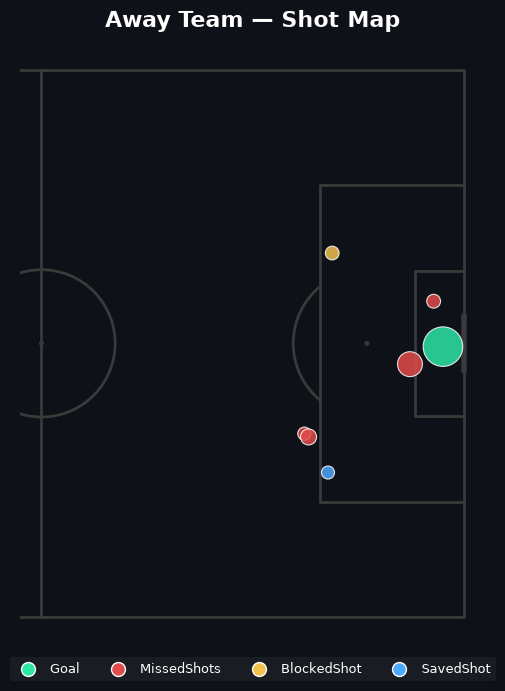

In [69]:


# Set up a vertical or horizontal pitch (horizontal shown here, half-pitch since attacking direction is one way)
pitch = Pitch(pitch_type='opta', pitch_color='#0e1117', line_color='#3a3a3a', half=True)
fig, ax = pitch.draw(figsize=(10, 7))
fig.set_facecolor("#0e1117")

# Understat X/Y are 0-1 normalized; Opta pitch_type in mplsoccer expects 0-100
away_shots = away_shots.copy()
away_shots['X_plot'] = away_shots['X'] * 100
away_shots['Y_plot'] = away_shots['Y'] * 100

# Color by outcome
color_map = {
    'Goal': '#2ee6a6',
    'MissedShots': '#e04b4b',
    'BlockedShot': '#f2c14e',
    'SavedShot': '#4ea8ff',
    'ShotOnPost': '#a45ee5'
}
colors = away_shots['result'].map(color_map).fillna('#888888')

# Size by xG so bigger chances = bigger dots
sizes = away_shots['xG'] * 800 + 60

scatter = pitch.scatter(
    away_shots['X_plot'], away_shots['Y_plot'],
    s=sizes,
    c=colors,
    edgecolors='white',
    linewidth=0.8,
    alpha=0.85,
    ax=ax,
    zorder=3
)

# Legend (manual, since color maps to categorical result)
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c, 
                        markersize=10, label=r, linestyle='') 
           for r, c in color_map.items() if r in away_shots['result'].unique()]
legend = ax.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, -0.02),
                    ncol=len(handles), facecolor="#1c1f26", edgecolor="none", 
                    labelcolor="white", fontsize=9)

ax.set_title("Away Team — Shot Map", color="white", fontsize=16, fontweight="bold", pad=15)

plt.tight_layout()
plt.show()

In [70]:
all_shots.dtypes

id                 str
minute             str
result             str
X                  str
Y                  str
xG                 str
player             str
h_a                str
player_id          str
situation          str
season             str
shotType           str
match_id           str
h_team             str
a_team             str
h_goals            str
a_goals            str
date               str
player_assisted    str
lastAction         str
dtype: object

In [71]:
# 1. Float conversions (continuous coordinates and probabilistic values)
float_cols = ['X', 'Y', 'xG']
all_shots[float_cols] = all_shots[float_cols].apply(pd.to_numeric, errors='coerce')

# 2. Integer conversions (counts and identifiers)
int_cols = ['id', 'minute', 'player_id', 'season', 'match_id', 'h_goals', 'a_goals']
all_shots[int_cols] = all_shots[int_cols].apply(pd.to_numeric, errors='coerce').astype('Int64')

# 3. Datetime conversion
all_shots['date'] = pd.to_datetime(all_shots['date'], errors='coerce')

# 4. Low-cardinality String / Categorical optimizations (optional, saves memory)
cat_cols = ['result', 'h_a', 'situation', 'shotType', 'lastAction']
all_shots[cat_cols] = all_shots[cat_cols].astype('category')

In [72]:
# 1. Float conversions (continuous coordinates and probabilistic values)
float_cols = ['X', 'Y', 'xG']
home_shots[float_cols] = home_shots[float_cols].apply(pd.to_numeric, errors='coerce')

# 2. Integer conversions (counts and identifiers)
int_cols = ['id', 'minute', 'player_id', 'season', 'match_id', 'h_goals', 'a_goals']
home_shots[int_cols] = home_shots[int_cols].apply(pd.to_numeric, errors='coerce').astype('Int64')

# 3. Datetime conversion
home_shots['date'] = pd.to_datetime(home_shots['date'], errors='coerce')

# 4. Low-cardinality String / Categorical optimizations (optional, saves memory)
cat_cols = ['result', 'h_a', 'situation', 'shotType', 'lastAction']
home_shots[cat_cols] = home_shots[cat_cols].astype('category')


Font 'rm' does not have a glyph for '\u26bd' [U+26bd], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\u26bd' [U+26bd], substituting with a dummy symbol.


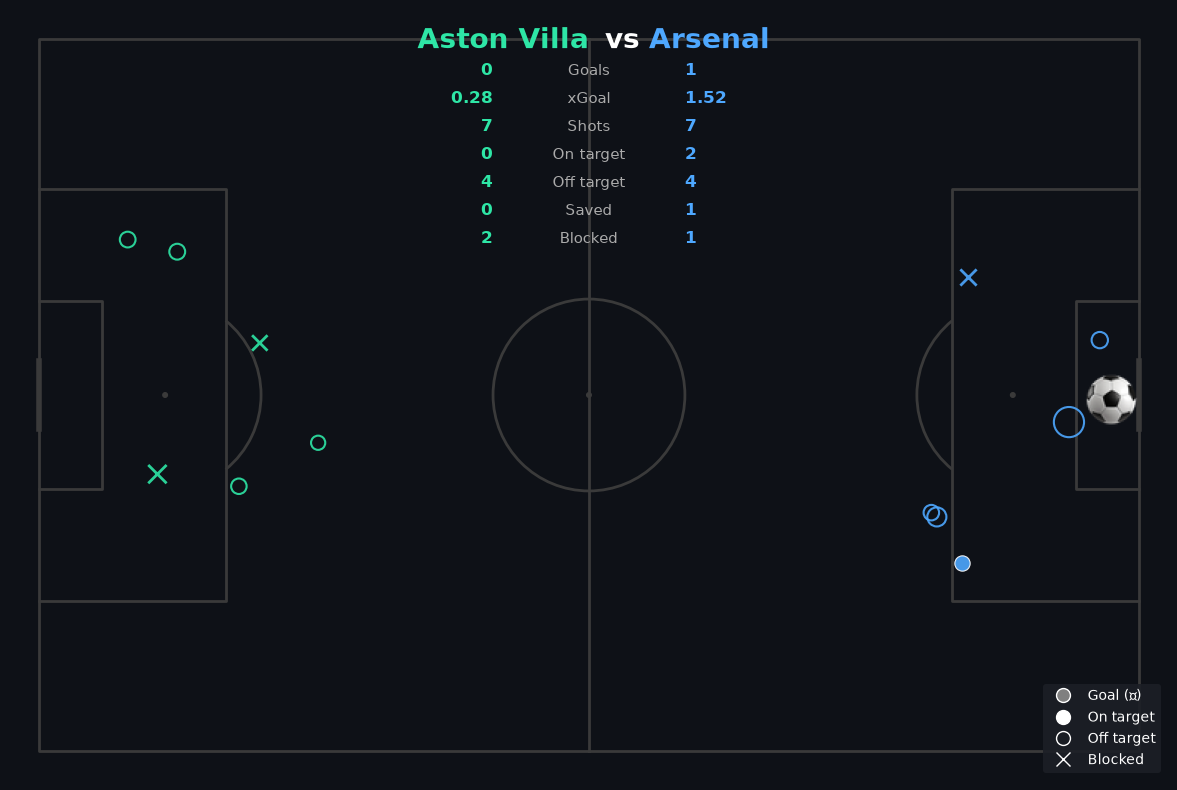

In [76]:


# --- Load ball image once ---
ball_path = r"C:/Users/salma/OneDrive/Desktop/projects/football/football-data-visualization/images/Ball.png"
ball_img = Image.open(ball_path).convert("RGBA")
ball_img = ball_img.resize((40, 40), Image.LANCZOS)
# --- Prep data ---
shots = pd.concat([home_shots, away_shots], ignore_index=True)
home_team = shots['h_team'].iloc[0]
away_team = shots['a_team'].iloc[0]

home_shots_df = shots[shots['h_a'] == 'h'].copy()
away_shots_df = shots[shots['h_a'] == 'a'].copy()

home_shots_df['X_plot'] = (1 - home_shots_df['X']) * 100
home_shots_df['Y_plot'] = home_shots_df['Y'] * 100
away_shots_df['X_plot'] = away_shots_df['X'] * 100
away_shots_df['Y_plot'] = away_shots_df['Y'] * 100

home_color = "#2ee6a6"
away_color = "#4ea8ff"
size_scale = 1200

# --- Draw pitch ---
pitch = Pitch(pitch_type='opta', pitch_color='#0e1117', line_color='#3a3a3a')
fig, ax = pitch.draw(figsize=(12, 8))
fig.set_facecolor("#0e1117")

# --- Non-goal markers (on target / off target / blocked) ---
def plot_team_shots(df, color):
    saved = df[df['result'] == 'SavedShot']
    if len(saved) > 0:
        pitch.scatter(saved['X_plot'], saved['Y_plot'], s=saved['xG'] * size_scale + 80,
                      marker='o', facecolors=color, edgecolors='white',
                      linewidth=0.8, alpha=0.9, ax=ax, zorder=3)

    missed = df[df['result'] == 'MissedShots']
    if len(missed) > 0:
        pitch.scatter(missed['X_plot'], missed['Y_plot'], s=missed['xG'] * size_scale + 80,
                      marker='o', facecolors='none', edgecolors=color,
                      linewidth=1.5, alpha=0.9, ax=ax, zorder=3)

    blocked = df[df['result'] == 'BlockedShot']
    if len(blocked) > 0:
        pitch.scatter(blocked['X_plot'], blocked['Y_plot'], s=blocked['xG'] * size_scale + 80,
                      marker='x', color=color, linewidth=2, alpha=0.9, ax=ax, zorder=3)

# --- Goal markers as ball images ---
def add_ball_markers(df, ax):
    goals = df[df['result'] == 'Goal']
    for _, row in goals.iterrows():
        zoom =  0.6 + row['xG'] * 0.5
        imagebox = OffsetImage(ball_img, zoom=zoom)
        ab = AnnotationBbox(imagebox, (row['X_plot'], row['Y_plot']), frameon=False, zorder=5)
        ax.add_artist(ab)

plot_team_shots(home_shots_df, home_color)
plot_team_shots(away_shots_df, away_color)
add_ball_markers(home_shots_df, ax)
add_ball_markers(away_shots_df, ax)

# --- Title ---
fig.text(0.5, 0.96, f"{home_team}", color=home_color, fontsize=20, fontweight="bold", ha="right", va="top")
fig.text(0.505, 0.96, " vs ", color="white", fontsize=20, fontweight="bold", ha="left", va="top")
fig.text(0.55, 0.96, f"{away_team}", color=away_color, fontsize=20, fontweight="bold", ha="left", va="top")

# --- Stats table ---
def team_summary(df):
    return {
        "Goals": (df['result'] == 'Goal').sum(),
        "xGoal": round(df['xG'].sum(), 2),
        "Shots": len(df),
        "On target": df['result'].isin(['Goal', 'SavedShot']).sum(),
        "Off target": (df['result'] == 'MissedShots').sum(),
        "Saved": (df['result'] == 'SavedShot').sum(),
        "Blocked": (df['result'] == 'BlockedShot').sum(),
    }

home_stats = team_summary(home_shots_df)
away_stats = team_summary(away_shots_df)

y_start = 0.90
for i, label in enumerate(home_stats.keys()):
    y = y_start - i * 0.035
    fig.text(0.42, y, str(home_stats[label]), color=home_color, fontsize=12, ha="right", fontweight="bold")
    fig.text(0.5, y, label, color="#aaaaaa", fontsize=11, ha="center")
    fig.text(0.58, y, str(away_stats[label]), color=away_color, fontsize=12, ha="left", fontweight="bold")

# --- Legend ---
legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=10, label='Goal ($⚽$)', linestyle=''),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='white', markersize=10, label='On target', linestyle=''),
    plt.Line2D([0], [0], marker='o', color='white', markerfacecolor='none', markersize=10, label='Off target', linestyle=''),
    plt.Line2D([0], [0], marker='x', color='white', markersize=10, label='Blocked', linestyle=''),
]
ax.legend(handles=legend_elements, loc='lower right', facecolor="#1c1f26",
          edgecolor="none", labelcolor="white", fontsize=10, framealpha=0.9)

plt.subplots_adjust(top=0.78)
plt.show()